In [ ]:
# Importing necessary libraries for data analysis, machine learning, and time series forecasting
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Statsmodels
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

print("All libraries imported successfully.")


All libraries imported successfully.


In [ ]:
# Load Dataset
DATA_PATH = 'merged_air_crash_data.csv'   # update path if needed
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset shape : {df_raw.shape}")
print(f"Rows          : {df_raw.shape[0]:,}")
print(f"Columns       : {df_raw.shape[1]}")


Dataset shape : (29708, 50)
Rows          : 29,708
Columns       : 50


In [ ]:
# Sample Records 
df_raw.head(5)


,ev_id,ev_type,ev_date,ev_city,ev_state,ev_country,wx_cond_basic,light_cond,sky_cond_nonceil,sky_ceil_ht,...,seatbelts_used,Occurrence_Description,phase_no,Defining_ev,crew_no_y,flight_hours,eng_type,eng_model,eng_time_total,eng_time_last_insp
0,20080107X00026,ACC,2008-01-01,Sonoma,CA,USA,VMC,DAYL,CLER,0.0,...,NaN,Landing Midair collision,550.0,True,1.0,3.0,REC,O-360-A3A,0.0,0.0
1,20080107X00026,ACC,2008-01-01,Sonoma,CA,USA,VMC,DAYL,CLER,0.0,...,NaN,Initial climb Midair collision,350.0,True,1.0,4850.0,REC,O-360,0.0,0.0
2,20080107X00027,ACC,2008-01-03,Oklahoma City,OK,USA,VMC,NITE,CLER,0.0,...,NaN,Standing-engine(s) operating AC/prop/rotor con...,153.0,True,1.0,17.0,TP,PT6A-67A,0.0,0.0
3,20080109X00036,ACC,2008-01-01,Arcola,TX,USA,VMC,DAYL,CLER,0.0,...,NaN,Landing-flare/touchdown Loss of control on ground,551.0,True,1.0,2.0,REC,IO-540,0.0,0.0
4,20080111X00038,INC,2008-01-03,Deauville Saint,NaN,FR,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Column Info 
print(df_raw.dtypes.to_string())


ev_id                         str
ev_type                       str
ev_date                       str
ev_city                       str
ev_state                      str
ev_country                    str
wx_cond_basic                 str
light_cond                    str
sky_cond_nonceil              str
sky_ceil_ht               float64
vis_sm                    float64
wind_dir_deg              float64
wind_vel_kts              float64
gust_kts                  float64
wx_temp                   float64
wx_dens_alt               float64
ev_highest_injury             str
inj_tot_f                   int64
inj_tot_m                   int64
inj_tot_n                   int64
inj_tot_s                   int64
inj_tot_t                 float64
Aircraft_Key                int64
acft_make                     str
acft_model                    str
damage                        str
acft_fire                     str
acft_expl                     str
num_eng                   float64
homebuilt     

In [ ]:
# Summary Statistics 
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ev_id,29708,29226,20100204X45658,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_type,29708,2,ACC,27491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_date,29708,6281,2011-06-18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_city,29692,10306,Anchorage,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_state,25057,57,CA,2290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ev_country,29704,181,USA,24339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wx_cond_basic,24804,3,VMC,23310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
light_cond,24474,7,DAYL,21801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sky_cond_nonceil,20410,5,CLER,13367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sky_ceil_ht,29536.0,NaN,NaN,NaN,1321.173449,4165.837173,0.0,0.0,0.0,0.0,260000.0


Observations;
- `ev_date` is stored as an object (string) and must be parsed to datetime.
- Injury columns (`inj_tot_f`, `inj_tot_m`, etc.) are already numeric.
- Several float columns likely represent counts or ordinal values; some have substantial missing data.
- Categorical columns such as `acft_make`, `damage`, `eng_type`, `wx_cond_basic` will need encoding.

Data Cleaning 

In [ ]:
# Work on a copy
df = df_raw.copy()

# Parse date and extract year/month 
df['ev_date'] = pd.to_datetime(df['ev_date'], errors='coerce')
df['year']    = df['ev_date'].dt.year
df['month']   = df['ev_date'].dt.month

print("Date range:", df['ev_date'].min(), "→", df['ev_date'].max())
print(f"Null dates : {df['ev_date'].isna().sum()}")


Date range: 2008-01-01 00:00:00 → 2025-07-31 00:00:00
Null dates : 0


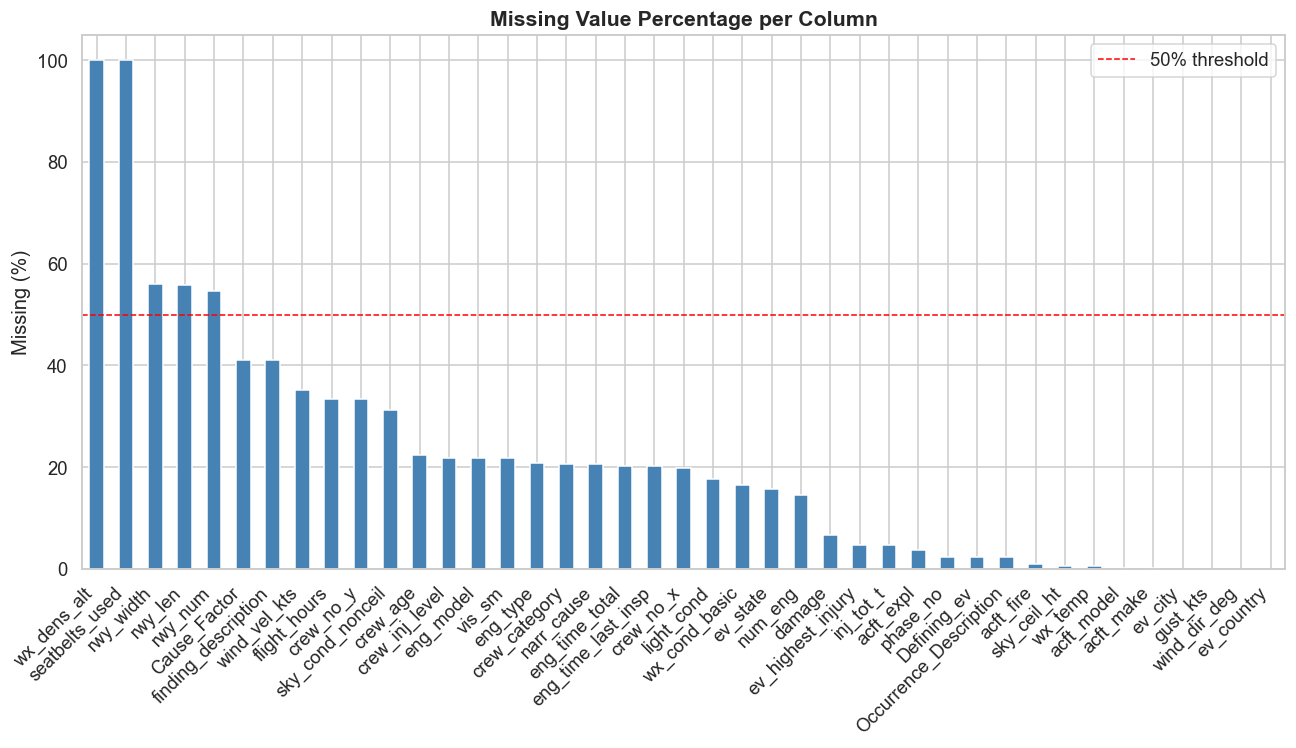

wx_dens_alt               100.000000
seatbelts_used            100.000000
rwy_width                  56.025313
rwy_len                    55.806517
rwy_num                    54.709169
Cause_Factor               40.999057
finding_description        40.999057
wind_vel_kts               35.152148
flight_hours               33.489296
crew_no_y                  33.489296
sky_cond_nonceil           31.297967
crew_age                   22.391275
crew_inj_level             21.859432
eng_model                  21.852700
vis_sm                     21.724788
eng_type                   20.849603
crew_category              20.570217
narr_cause                 20.553386
eng_time_total             20.274000
eng_time_last_insp         20.274000
crew_no_x                  19.910462
light_cond                 17.618150
wx_cond_basic              16.507338
ev_state                   15.655716
num_eng                    14.484314
damage                      6.617746
ev_highest_injury           4.776491
i

In [ ]:
# Missing Value Analysis 
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(12, 7))
missing.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Value Percentage per Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('')
ax.axhline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(missing.to_string())


In [ ]:
# Drop high-missingness columns (>60%) 
threshold = 60
high_missing_cols = missing[missing > threshold].index.tolist()
print(f"Dropping {len(high_missing_cols)} columns with >{threshold}% missing:", high_missing_cols)
df.drop(columns=high_missing_cols, inplace=True)

# Drop rows where target or date is missing 
df.dropna(subset=['inj_tot_f', 'ev_date'], inplace=True)
print(f"Shape after row-drops : {df.shape}")


Dropping 2 columns with >60% missing: ['wx_dens_alt', 'seatbelts_used']
Shape after row-drops : (29708, 50)


In [ ]:
# Duplicate Analysis 
n_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {n_dupes}")

# ev_id + Aircraft_Key duplicates (same aircraft same event)
n_ev_dupes = df.duplicated(subset=['ev_id', 'Aircraft_Key']).sum()
print(f"Event+Aircraft duplicates: {n_ev_dupes}")
# Keep first occurrence
df = df.loc[~df.duplicated(subset=['ev_id', 'Aircraft_Key'], keep='first')].copy()
print(f"Shape after dedup: {df.shape}")


Full duplicate rows: 0
Event+Aircraft duplicates: 0
Shape after dedup: (29708, 50)


In [ ]:
# Data Type Corrections 
# Numeric coercions for columns that may have stray strings
num_cols = ['inj_tot_f', 'inj_tot_m', 'inj_tot_n', 'inj_tot_s', 'inj_tot_t',
            'num_eng', 'crew_age', 'flight_hours', 'eng_time_total',
            'wind_vel_kts', 'wx_temp', 'vis_sm', 'sky_ceil_ht']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Numeric dtypes confirmed.")


Numeric dtypes confirmed.


In [ ]:
# Median Imputation for Numerics 
num_impute_cols = ['wind_vel_kts', 'wx_temp', 'vis_sm', 'sky_ceil_ht',
                   'crew_age', 'flight_hours', 'eng_time_total', 'eng_time_last_insp',
                   'num_eng', 'inj_tot_m', 'inj_tot_n', 'inj_tot_s', 'inj_tot_t']
for c in num_impute_cols:
    if c in df.columns:
        df[c].fillna(df[c].median(), inplace=True)

# Mode Imputation for Categoricals 
cat_impute_cols = ['acft_make', 'damage', 'eng_type', 'wx_cond_basic',
                   'light_cond', 'ev_highest_injury', 'crew_category',
                   'crew_inj_level', 'Cause_Factor', 'acft_fire', 'acft_expl',
                   'homebuilt']
for c in cat_impute_cols:
    if c in df.columns:
        df[c].fillna(df[c].mode()[0], inplace=True)

print("Imputation complete.")
print(f"Remaining nulls:\n{df.isna().sum()[df.isna().sum()>0]}")


Imputation complete.
Remaining nulls:
ev_city                      16
ev_state                   4651
ev_country                    4
wx_cond_basic              4904
light_cond                 5234
sky_cond_nonceil           9298
sky_ceil_ht                 172
vis_sm                     6454
wind_dir_deg                 15
wind_vel_kts              10443
gust_kts                     15
wx_temp                     172
ev_highest_injury          1419
inj_tot_t                  1419
acft_make                    43
acft_model                   54
damage                     1966
acft_fire                   281
acft_expl                  1106
num_eng                    4303
rwy_num                   16253
rwy_len                   16579
rwy_width                 16644
finding_description       12180
Cause_Factor              12180
narr_cause                 6106
crew_no_x                  5915
crew_category              6111
crew_age                   6652
crew_inj_level             6494
Oc

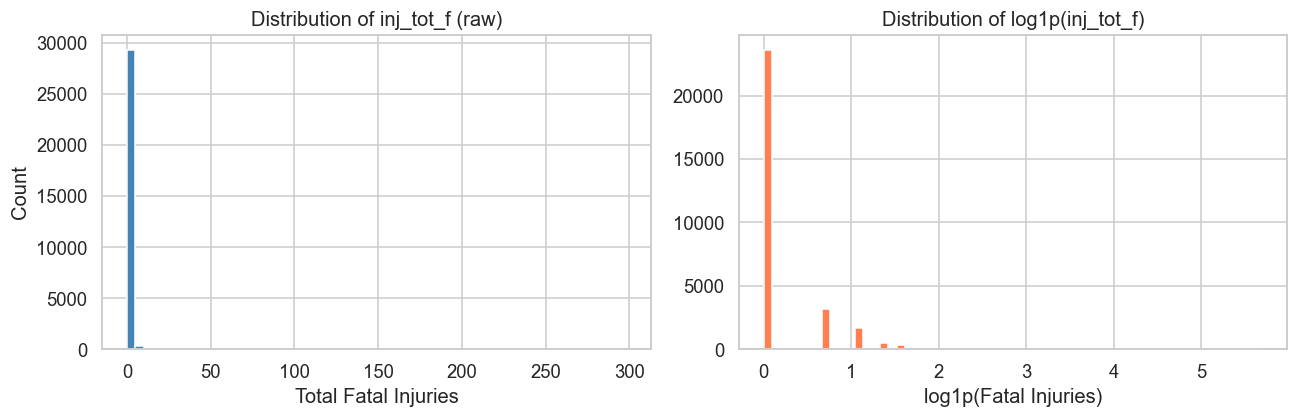

count    29708.000000
mean         0.551973
std          4.715806
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        298.000000
Name: inj_tot_f, dtype: float64

Accidents with 0 fatalities : 23,609 (79.5%)
Accidents with ≥1 fatality   : 6,099
Max fatalities in one event  : 298


In [ ]:
# Outlier Detection — Target Variable 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['inj_tot_f'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of inj_tot_f (raw)')
axes[0].set_xlabel('Total Fatal Injuries')
axes[0].set_ylabel('Count')

# Log1p transform for visualisation
axes[1].hist(np.log1p(df['inj_tot_f']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(inj_tot_f)')
axes[1].set_xlabel('log1p(Fatal Injuries)')

plt.tight_layout()
plt.show()

print(df['inj_tot_f'].describe())
print(f"\nAccidents with 0 fatalities : {(df['inj_tot_f']==0).sum():,} ({(df['inj_tot_f']==0).mean()*100:.1f}%)")
print(f"Accidents with ≥1 fatality   : {(df['inj_tot_f']>0).sum():,}")
print(f"Max fatalities in one event  : {df['inj_tot_f'].max()}")


Outlier Treatment;

The target variable `inj_tot_f` is extremely right-skewed — the vast majority of accidents result in zero fatalities. A small number of catastrophic accidents (large commercial airliners) produce values in the hundreds. This is a genuine distribution characteristic of aviation accidents, not a data entry error. 

Approach: We will use a `log1p` transformation of the target for modelling to stabilise variance, and inverse-transform predictions back to the original scale for reporting. Extreme outliers (>99th percentile) will be retained, as they represent real high-casualty events that the model must account for.

In [ ]:
# Data Quality Summary 
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total records       : {len(df):,}")
print(f"Total features      : {df.shape[1]}")
print(f"Date range          : {df['year'].min()} – {df['year'].max()}")
print(f"Target mean         : {df['inj_tot_f'].mean():.3f}")
print(f"Target std          : {df['inj_tot_f'].std():.3f}")
print(f"Target 99th pct     : {df['inj_tot_f'].quantile(0.99)}")
print(f"Remaining nulls     : {df.isna().sum().sum()}")
print("=" * 50)


DATA QUALITY SUMMARY
Total records       : 29,708
Total features      : 50
Date range          : 2008 – 2025
Target mean         : 0.552
Target std          : 4.716
Target 99th pct     : 5.0
Remaining nulls     : 203850


Exploratory Data Analysis 

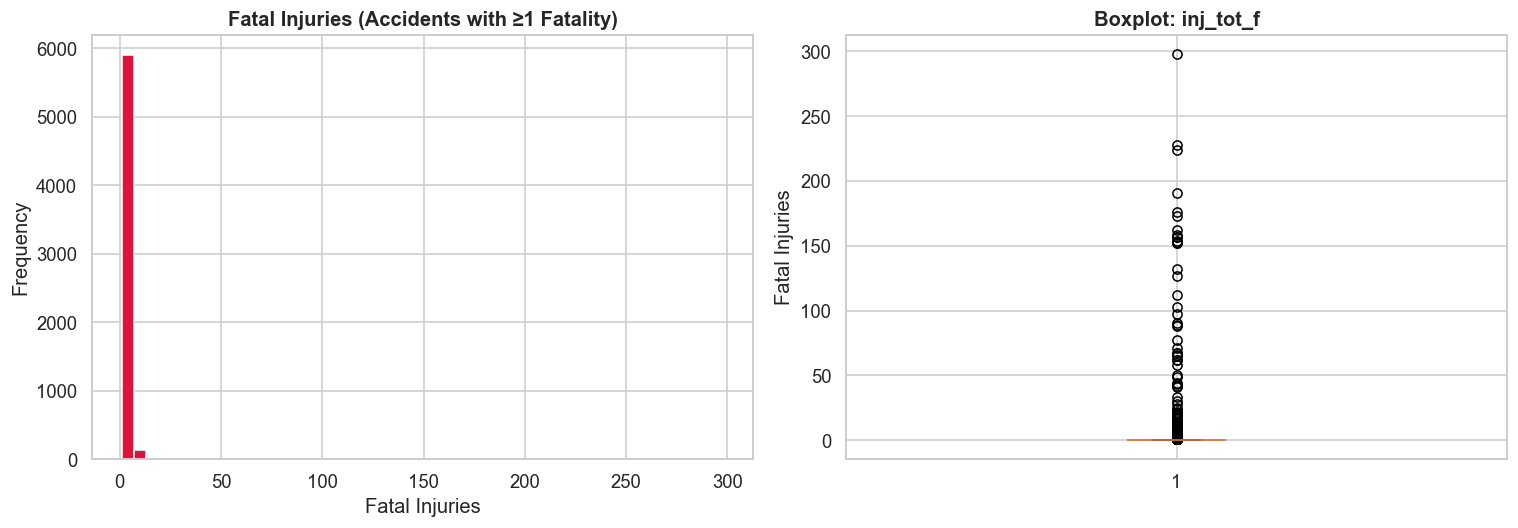

In [ ]:
# Fatal Injuries Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Non-zero fatalities
fatal_nz = df[df['inj_tot_f'] > 0]['inj_tot_f']
axes[0].hist(fatal_nz, bins=50, color='crimson', edgecolor='white')
axes[0].set_title('Fatal Injuries (Accidents with ≥1 Fatality)', fontweight='bold')
axes[0].set_xlabel('Fatal Injuries')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['inj_tot_f'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot: inj_tot_f', fontweight='bold')
axes[1].set_ylabel('Fatal Injuries')

plt.tight_layout()
plt.show()


Interpretation: The fatal injuries distribution is extremely right-skewed. Over 80% of accidents result in zero fatalities, while a handful of mass-casualty events drive the tail. This zero-inflation is characteristic of aviation accidents globally — most incidents involve minor property damage. The boxplot clearly shows these extreme outliers. In modelling, this motivates log transformation and robust evaluation metrics.

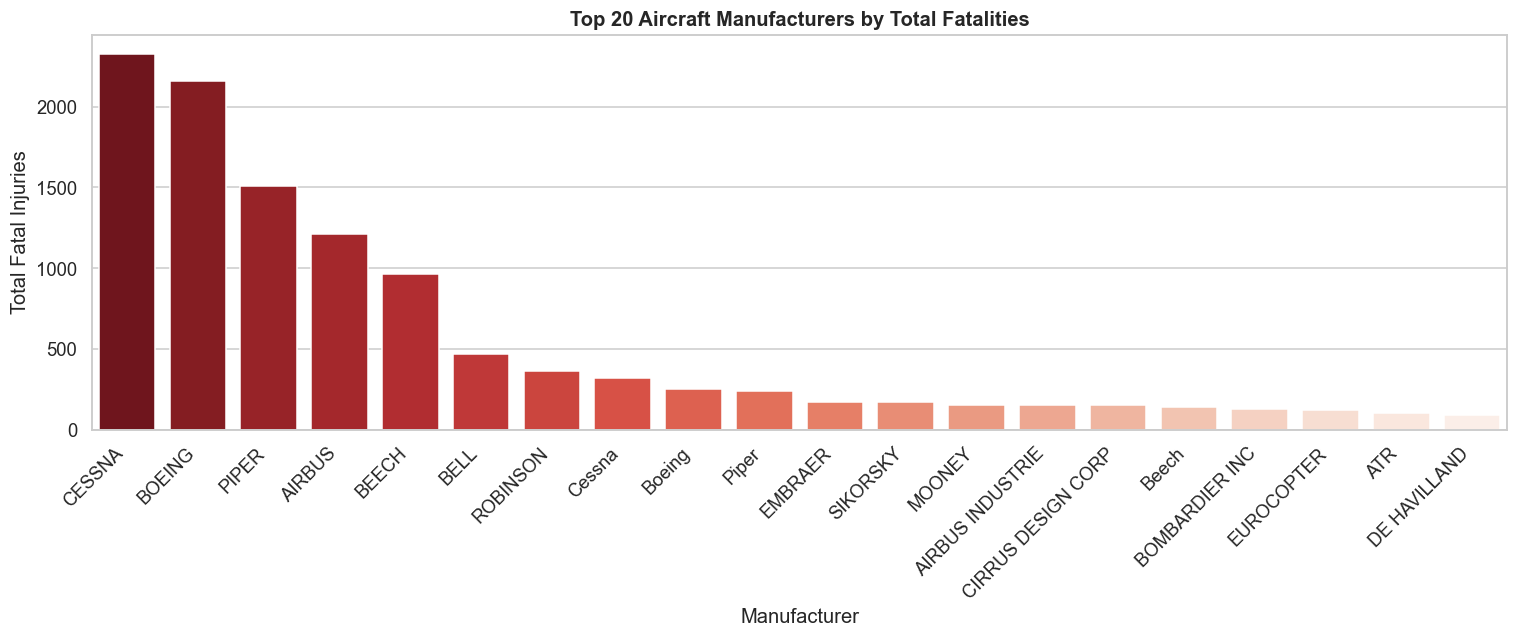

                    total_fatalities  accidents
acft_make                                      
CESSNA                          2329       5962
BOEING                          2161       1576
PIPER                           1509       3452
AIRBUS                          1214        365
BEECH                            962       1263
BELL                             470        682
ROBINSON                         361        348
Cessna                           322       1025
Boeing                           252        110
Piper                            236        606
EMBRAER                          173        171
SIKORSKY                         171         90
MOONEY                           154        288
AIRBUS INDUSTRIE                 152         26
CIRRUS DESIGN CORP               150        291


In [ ]:
# Fatal Injuries by Aircraft Manufacturer 
make_fatal = (df.groupby('acft_make')['inj_tot_f']
                .agg(['sum','count'])
                .rename(columns={'sum':'total_fatalities','count':'accidents'})
                .sort_values('total_fatalities', ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=make_fatal.reset_index(), x='acft_make', y='total_fatalities',
            palette='Reds_r', ax=ax)
ax.set_title('Top 20 Aircraft Manufacturers by Total Fatalities', fontweight='bold')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Total Fatal Injuries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(make_fatal.head(15).to_string())


Interpretation: Cessna and Piper dominate the fatality totals — not because they are inherently unsafe, but because they represent the largest fleet share in general aviation (the category with the most accident exposure). Per-accident fatality rate analysis would normalise for fleet size and provide a fairer safety comparison.

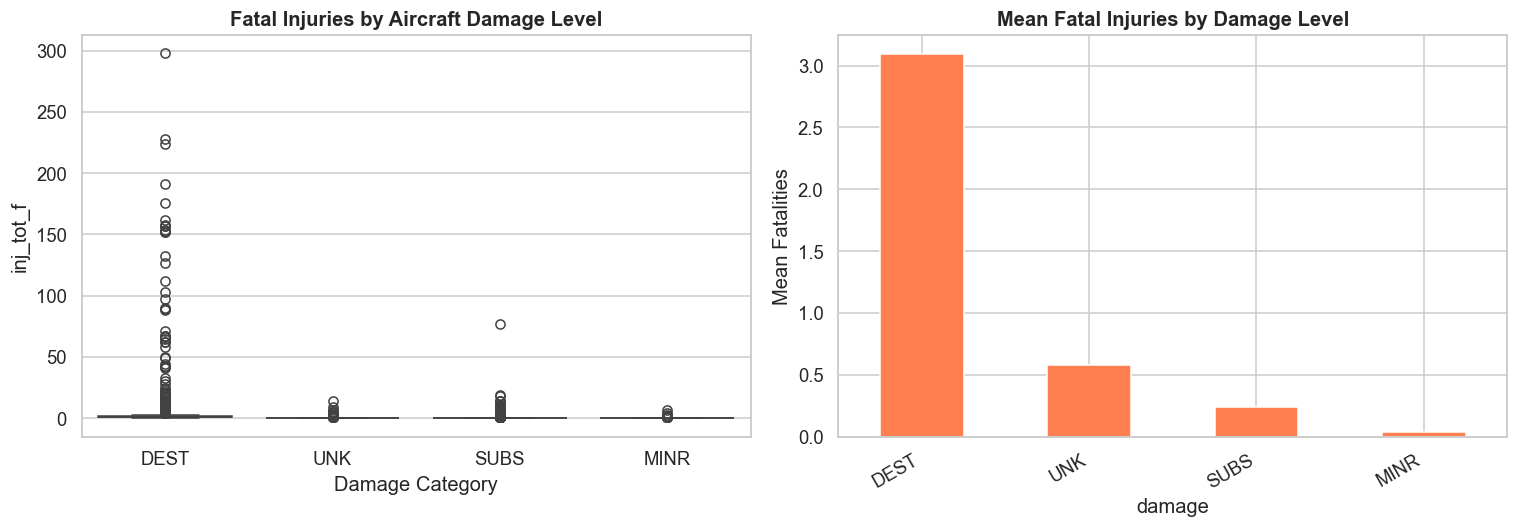

In [ ]:
# Fatal Injuries by Aircraft Damage Level 
if 'damage' in df.columns:
    dmg_order = df.groupby('damage')['inj_tot_f'].mean().sort_values(ascending=False).index
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(data=df, x='damage', y='inj_tot_f', order=dmg_order,
                palette='OrRd', ax=axes[0])
    axes[0].set_title('Fatal Injuries by Aircraft Damage Level', fontweight='bold')
    axes[0].set_xlabel('Damage Category')
    axes[0].set_ylabel('inj_tot_f')
    
    dmg_mean = df.groupby('damage')['inj_tot_f'].mean().sort_values(ascending=False)
    dmg_mean.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
    axes[1].set_title('Mean Fatal Injuries by Damage Level', fontweight='bold')
    axes[1].set_ylabel('Mean Fatalities')
    plt.xticks(rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()


Interpretation: As expected, aircraft destruction (`DEST`) is strongly associated with higher fatality counts. Substantial damage (`SUBS`) also shows elevated mean fatalities compared to minor damage (`MINR`). This confirms aircraft damage level as a strong predictor and a useful proxy for accident severity.

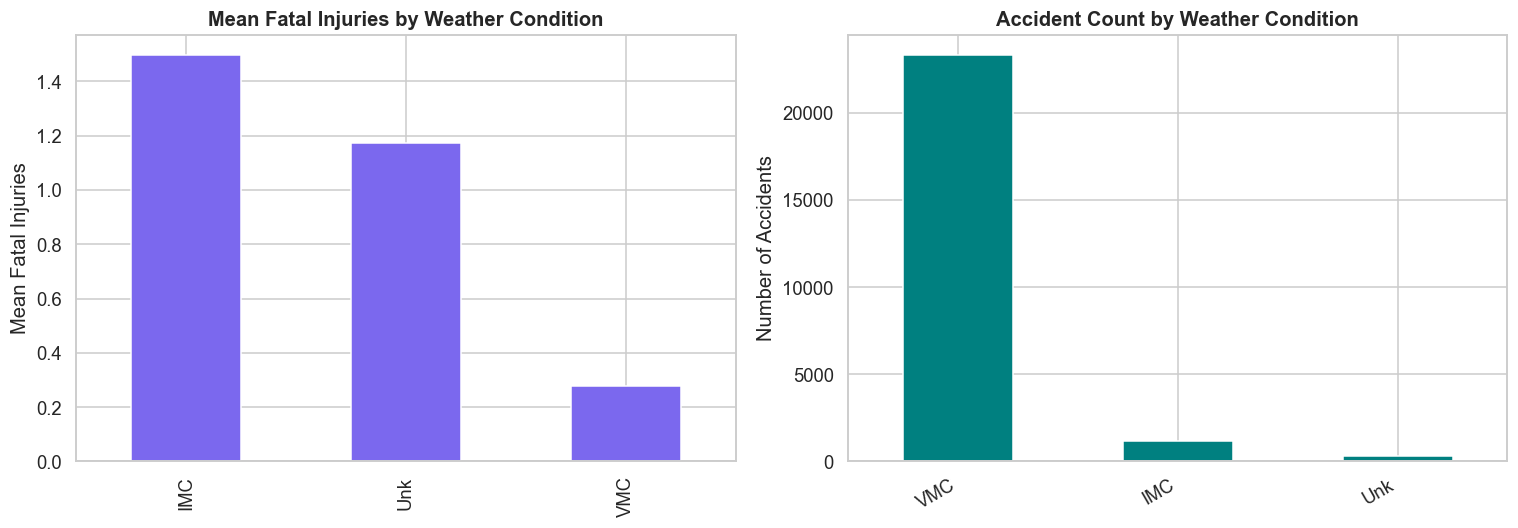

In [ ]:
# Fatal Injuries by Weather Condition 
if 'wx_cond_basic' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    wx_mean = df.groupby('wx_cond_basic')['inj_tot_f'].mean().sort_values(ascending=False)
    wx_count = df.groupby('wx_cond_basic')['inj_tot_f'].count().sort_values(ascending=False)
    
    wx_mean.plot(kind='bar', ax=axes[0], color='mediumslateblue', edgecolor='white')
    axes[0].set_title('Mean Fatal Injuries by Weather Condition', fontweight='bold')
    axes[0].set_ylabel('Mean Fatal Injuries')
    axes[0].set_xlabel('')
    
    wx_count.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
    axes[1].set_title('Accident Count by Weather Condition', fontweight='bold')
    axes[1].set_ylabel('Number of Accidents')
    axes[1].set_xlabel('')
    
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


Interpretation: IMC (Instrument Meteorological Conditions) is associated with higher mean fatality counts compared to VMC (Visual Meteorological Conditions). This aligns with safety research indicating that loss-of-control in IMC is a leading cause of fatal accidents, especially among general aviation pilots lacking instrument proficiency.

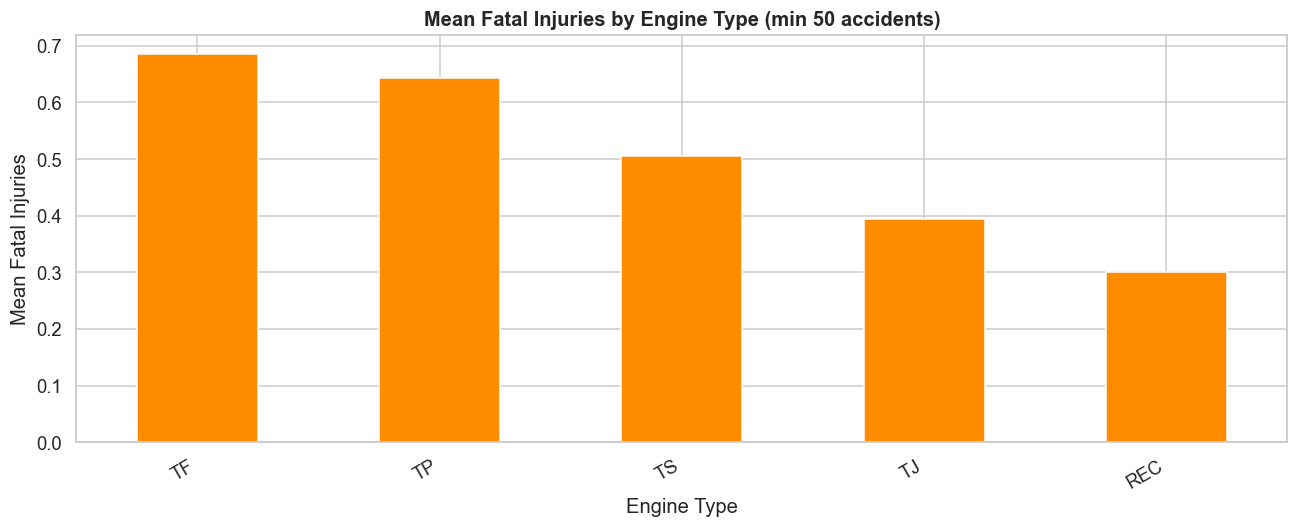

              mean  count
eng_type                 
TF        0.685341   1071
TP        0.643498   1338
TS        0.505691   1230
TJ        0.394904    157
REC       0.300423  19609


In [ ]:
# Fatal Injuries by Engine Type 
if 'eng_type' in df.columns:
    eng_mean = df.groupby('eng_type')['inj_tot_f'].agg(['mean','count']).sort_values('mean', ascending=False)
    eng_mean = eng_mean[eng_mean['count'] > 50]  # filter low-sample types
    
    fig, ax = plt.subplots(figsize=(12, 5))
    eng_mean['mean'].plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
    ax.set_title('Mean Fatal Injuries by Engine Type (min 50 accidents)', fontweight='bold')
    ax.set_ylabel('Mean Fatal Injuries')
    ax.set_xlabel('Engine Type')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(eng_mean.to_string())


Interpretation: Turbojet and turbofan engine types (typically associated with commercial aviation) tend to involve higher fatality counts when accidents do occur — reflecting larger passenger loads. Reciprocating engines dominate general aviation and show lower per-accident fatalities but account for the bulk of accident volume.

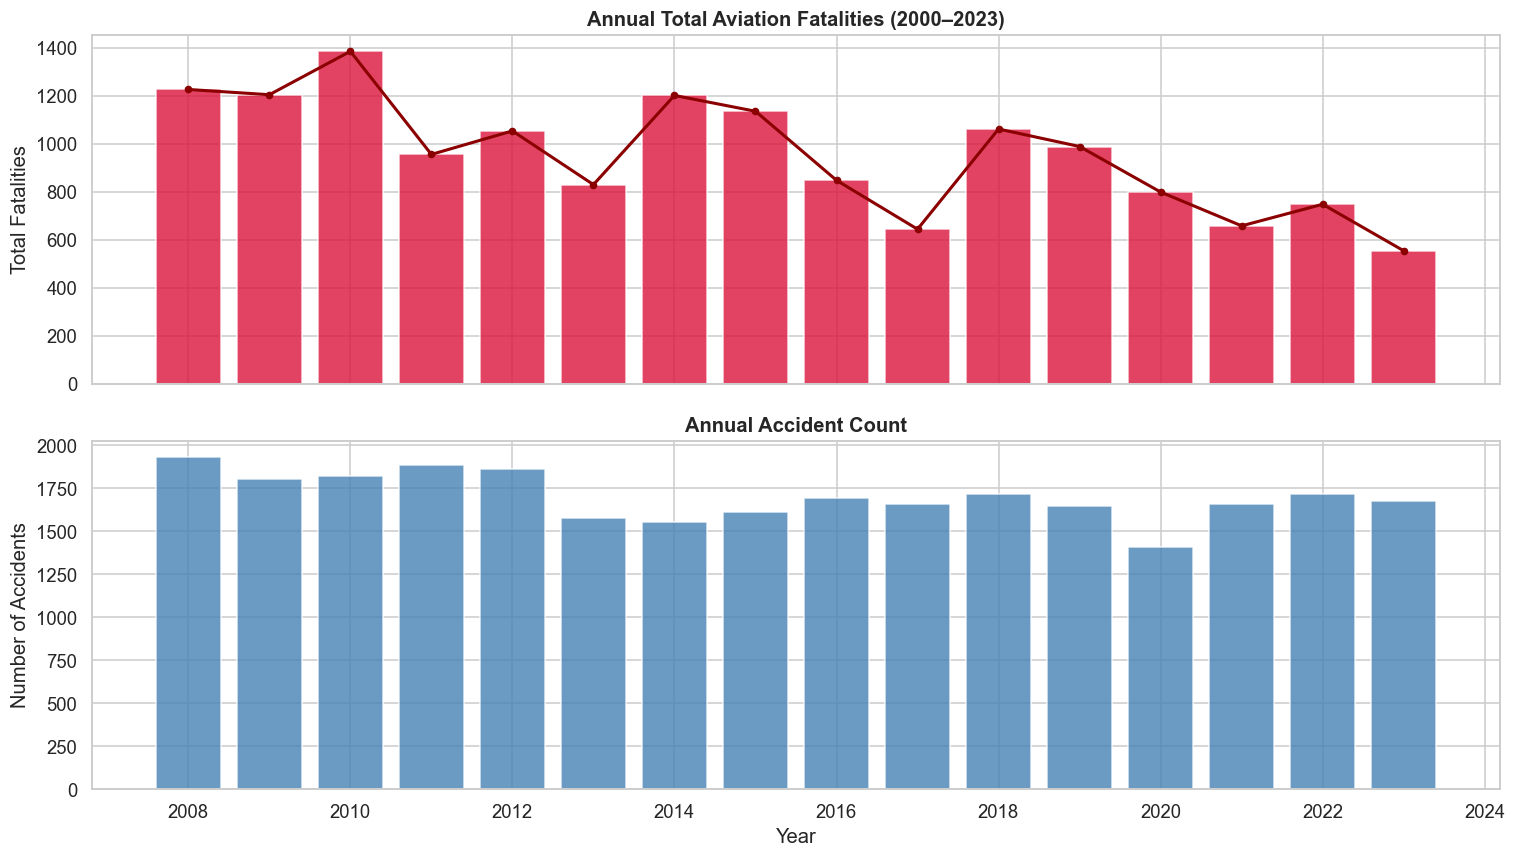

 year  total_fatalities  mean_fatalities  accidents
 2008              1227         0.635422       1931
 2009              1205         0.667590       1805
 2010              1386         0.760703       1822
 2011               956         0.506356       1888
 2012              1054         0.566667       1860
 2013               830         0.526984       1575
 2014              1202         0.774485       1552
 2015              1136         0.705152       1611
 2016               848         0.500590       1694
 2017               644         0.387718       1661
 2018              1062         0.619603       1714
 2019               989         0.599757       1649
 2020               799         0.566667       1410
 2021               658         0.396147       1661
 2022               748         0.436406       1714
 2023               554         0.330746       1675


In [ ]:
# Fatal Injuries by Year 
yearly = df.groupby('year')['inj_tot_f'].agg(['sum','mean','count']).reset_index()
yearly.columns = ['year','total_fatalities','mean_fatalities','accidents']
yearly = yearly[(yearly['year'] >= 2000) & (yearly['year'] <= 2023)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(yearly['year'], yearly['total_fatalities'], color='crimson', alpha=0.8)
axes[0].plot(yearly['year'], yearly['total_fatalities'], color='darkred', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Annual Total Aviation Fatalities (2000–2023)', fontweight='bold')
axes[0].set_ylabel('Total Fatalities')

axes[1].bar(yearly['year'], yearly['accidents'], color='steelblue', alpha=0.8)
axes[1].set_title('Annual Accident Count', fontweight='bold')
axes[1].set_ylabel('Number of Accidents')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

print(yearly.to_string(index=False))


Interpretation: Both total fatalities and accident counts show a general downward trend over the 2000–2023 period, reflecting improvements in avionics, training standards, and regulatory oversight. There are notable spikes in certain years that may correspond to specific high-casualty events. The 2020 reduction likely reflects reduced air traffic due to COVID-19 travel restrictions.

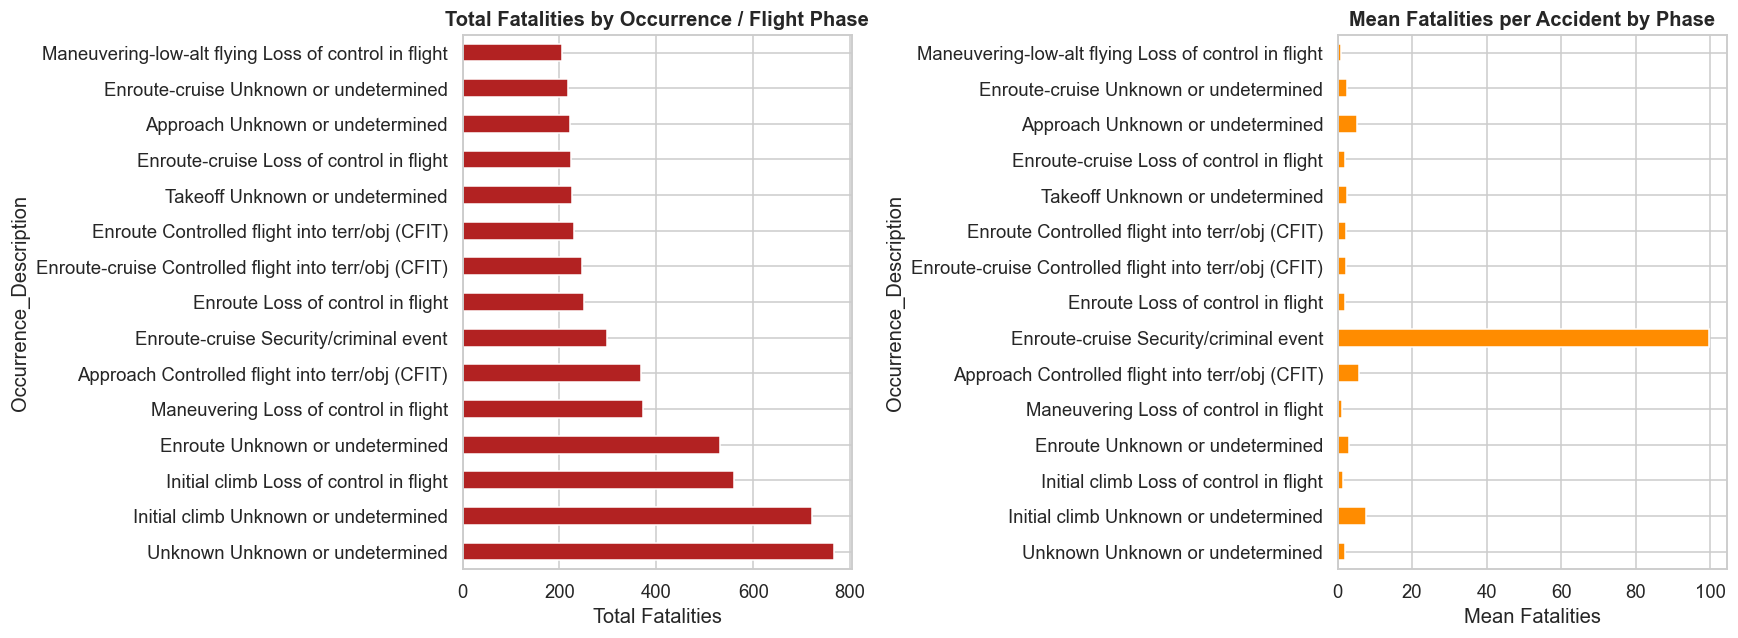

In [ ]:
# Fatal Injuries by Flight Phase 
if 'Occurrence_Description' in df.columns:
    phase_mean = (df.groupby('Occurrence_Description')['inj_tot_f']
                    .agg(['mean','sum','count'])
                    .sort_values('sum', ascending=False)
                    .head(15))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    phase_mean['sum'].plot(kind='barh', ax=axes[0], color='firebrick', edgecolor='white')
    axes[0].set_title('Total Fatalities by Occurrence / Flight Phase', fontweight='bold')
    axes[0].set_xlabel('Total Fatalities')
    
    phase_mean['mean'].plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
    axes[1].set_title('Mean Fatalities per Accident by Phase', fontweight='bold')
    axes[1].set_xlabel('Mean Fatalities')
    
    plt.tight_layout()
    plt.show()


Interpretation: In-flight phases (cruise, approach, initial climb) account for the highest total fatalities given their accident frequency. However, certain phases like inflight fire/explosion or collision with terrain show high *mean* fatalities — these catastrophic event types have low frequency but high lethality when they occur.

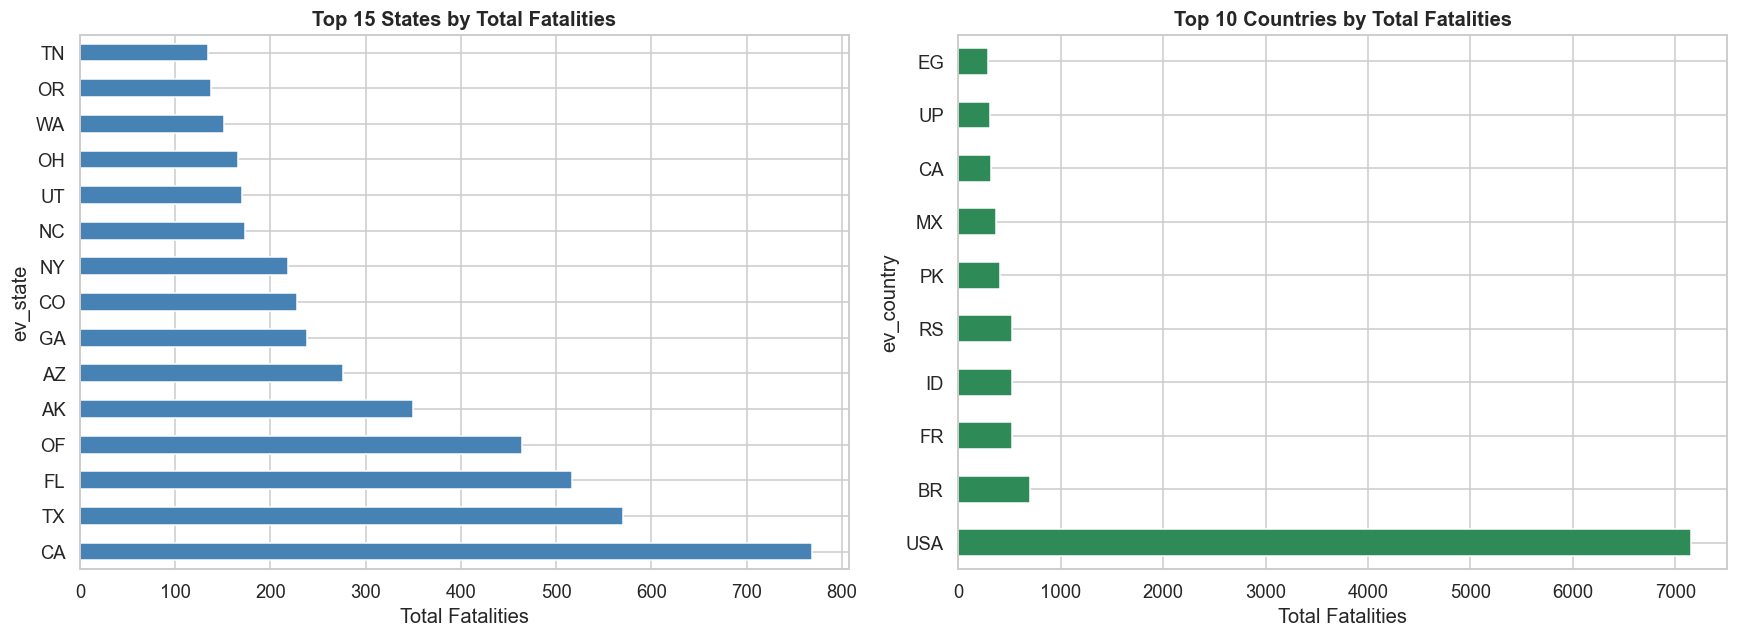

In [ ]:
# Top States / Countries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_fatal = df.groupby('ev_state')['inj_tot_f'].sum().sort_values(ascending=False).head(15)
state_fatal.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 States by Total Fatalities', fontweight='bold')
axes[0].set_xlabel('Total Fatalities')

country_fatal = df.groupby('ev_country')['inj_tot_f'].sum().sort_values(ascending=False).head(10)
country_fatal.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Top 10 Countries by Total Fatalities', fontweight='bold')
axes[1].set_xlabel('Total Fatalities')

plt.tight_layout()
plt.show()


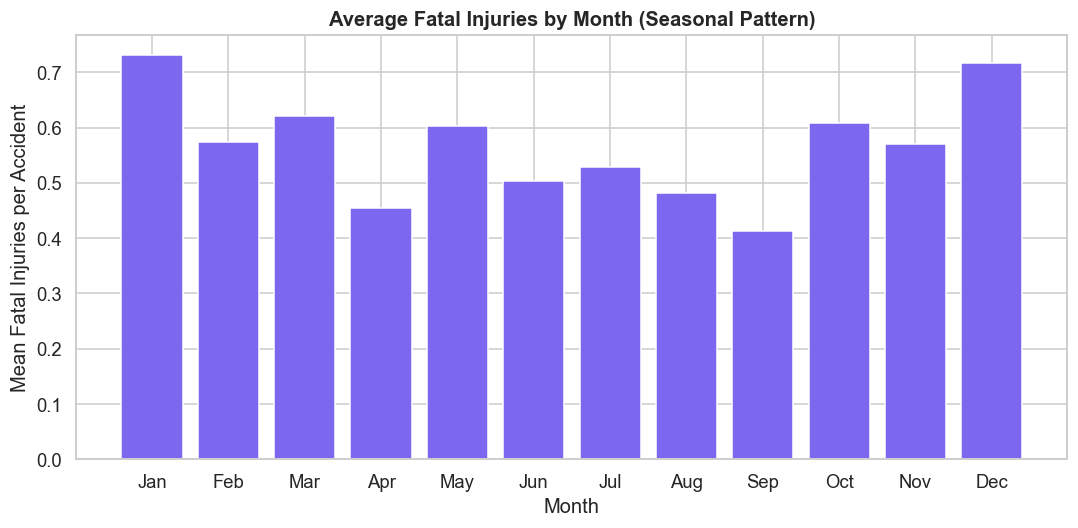

In [ ]:
# Seasonal Patterns 
monthly_avg = df.groupby('month')['inj_tot_f'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(range(1, 13), monthly_avg, color='mediumslateblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average Fatal Injuries by Month (Seasonal Pattern)', fontweight='bold')
ax.set_ylabel('Mean Fatal Injuries per Accident')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()


Interpretation: There is a discernible seasonal pattern in mean fatalities, with summer months (June–August) showing elevated levels. This aligns with peak general aviation activity during warmer months, increased VFR flight hours, and greater exposure to convective weather. Winter months show lower activity and slightly lower average fatality counts.

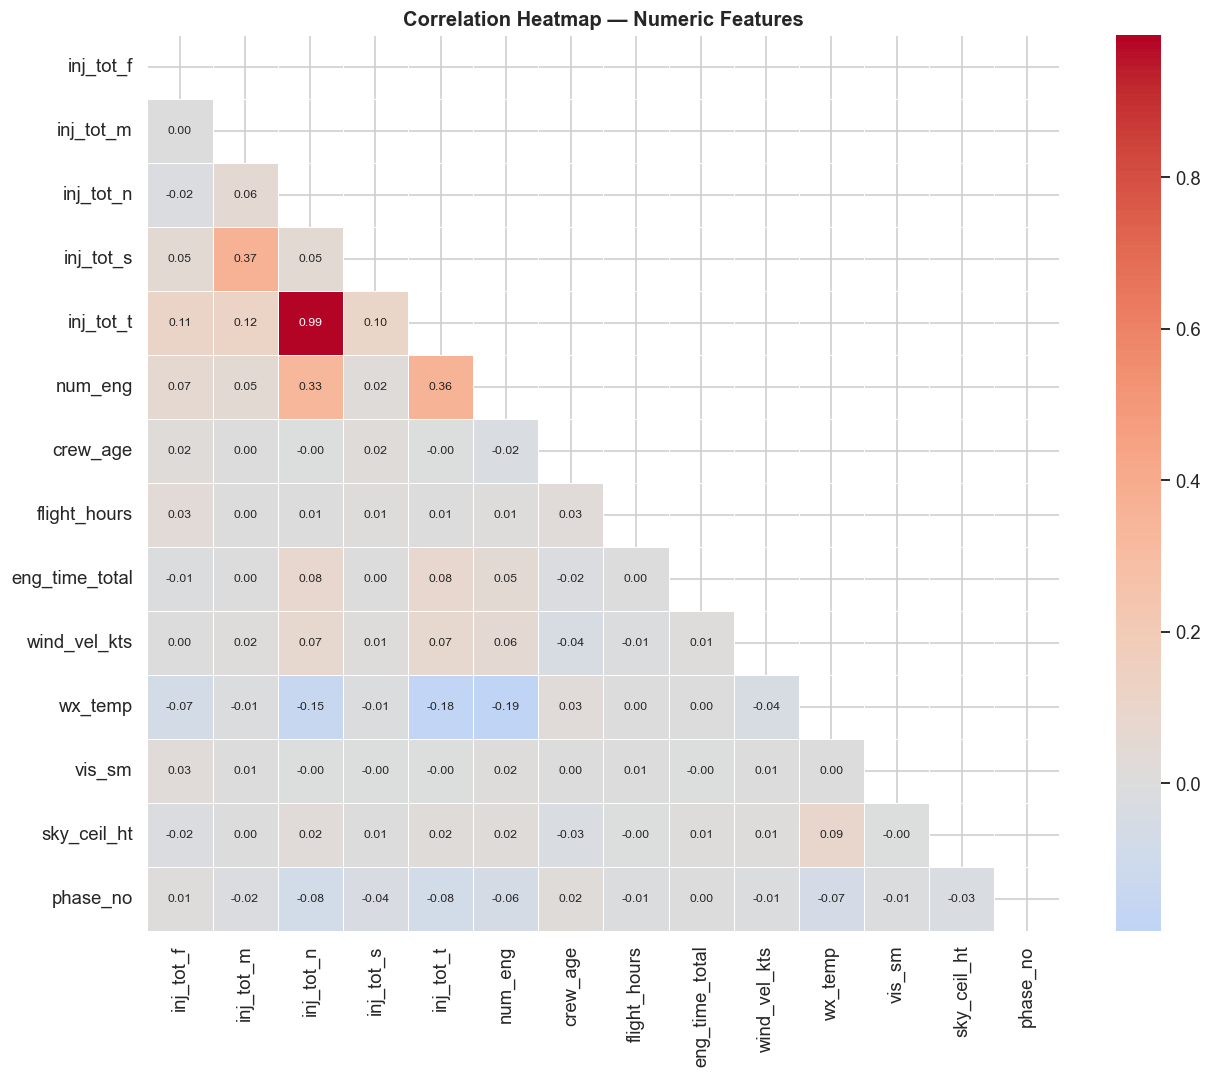

In [ ]:
# Correlation Heatmap 
corr_cols = ['inj_tot_f','inj_tot_m','inj_tot_n','inj_tot_s','inj_tot_t',
             'num_eng','crew_age','flight_hours','eng_time_total',
             'wind_vel_kts','wx_temp','vis_sm','sky_ceil_ht','phase_no']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()


Interpretation: The correlation heatmap reveals:
- `inj_tot_f` is strongly correlated with `inj_tot_t` (total injuries) — expected, as fatal injuries are a component.
- `inj_tot_f` has moderate correlation with `inj_tot_s` (serious injuries) suggesting severe accidents tend to produce multiple injury types.
- Meteorological variables (wind, visibility, temperature) show weak direct linear correlations with fatalities, suggesting non-linear interactions captured better by tree-based models.
- `flight_hours` has a weak negative correlation with fatalities, consistent with the finding that more experienced pilots tend to have lower fatal accident rates.

In [ ]:
# Temporal Features
df['year']          = df['ev_date'].dt.year
df['month']         = df['ev_date'].dt.month
df['quarter']       = df['ev_date'].dt.quarter
df['day_of_week']   = df['ev_date'].dt.dayofweek   # 0=Monday
df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
df['season']        = df['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1,
                                        6:2,7:2,8:2, 9:3,10:3,11:3})
# Accident age from a reference point (2025)
df['accident_age']  = 2025 - df['year']

print("Temporal features created: year, month, quarter, day_of_week, is_weekend, season, accident_age")


Temporal features created: year, month, quarter, day_of_week, is_weekend, season, accident_age


In [ ]:
# Homebuilt Flag 
if 'homebuilt' in df.columns:
    df['is_homebuilt'] = (df['homebuilt'].str.upper() == 'Y').astype(int)
    print("Homebuilt flag created.")


Homebuilt flag created.


In [ ]:
# Multi-Engine Flag 
if 'num_eng' in df.columns:
    df['is_multi_engine'] = (df['num_eng'] > 1).astype(int)
    print("Multi-engine flag created.")


Multi-engine flag created.


In [ ]:
# Crew Experience Bins 
if 'flight_hours' in df.columns:
    df['crew_exp_bin'] = pd.cut(df['flight_hours'],
                                bins=[0, 100, 500, 1500, 5000, np.inf],
                                labels=[0, 1, 2, 3, 4])
    df['crew_exp_bin'] = df['crew_exp_bin'].astype(float)
    print("Crew experience bin created.")


Crew experience bin created.


In [ ]:
# Damage Severity Score 
if 'damage' in df.columns:
    damage_map = {'NONE':0, 'MINR':1, 'SUBS':2, 'DEST':3}
    df['damage_score'] = df['damage'].map(damage_map).fillna(1)
    print("Damage severity score created.")


Damage severity score created.


In [ ]:
# Weather Severity 
if 'wx_cond_basic' in df.columns:
    wx_map = {'VMC':0, 'IMC':1}
    df['is_imc'] = df['wx_cond_basic'].map(wx_map).fillna(0).astype(int)
    print("IMC flag created.")


IMC flag created.


In [ ]:
# Label Encoding Categorical Features 
from sklearn.preprocessing import LabelEncoder

cat_encode_cols = ['acft_make', 'eng_type', 'light_cond', 'ev_highest_injury',
                   'crew_category', 'crew_inj_level', 'Cause_Factor',
                   'acft_fire', 'acft_expl', 'Defining_ev']
cat_encode_cols = [c for c in cat_encode_cols if c in df.columns]

le_dict = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print(f"Label-encoded {len(cat_encode_cols)} categorical columns.")


Label-encoded 10 categorical columns.


In [ ]:
# Feature Summary
engineered_features = ['year','month','quarter','day_of_week','is_weekend','season',
                       'accident_age','is_homebuilt','is_multi_engine','crew_exp_bin',
                       'damage_score','is_imc'] + [c+'_enc' for c in cat_encode_cols]

engineered_features = [f for f in engineered_features if f in df.columns]
print(f"Total engineered features available: {len(engineered_features)}")
print(engineered_features)


Total engineered features available: 22
['year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'season', 'accident_age', 'is_homebuilt', 'is_multi_engine', 'crew_exp_bin', 'damage_score', 'is_imc', 'acft_make_enc', 'eng_type_enc', 'light_cond_enc', 'ev_highest_injury_enc', 'crew_category_enc', 'crew_inj_level_enc', 'Cause_Factor_enc', 'acft_fire_enc', 'acft_expl_enc', 'Defining_ev_enc']


Regression Modeling

In [ ]:
# Feature Matrix and Target 
base_numeric = ['num_eng','crew_age','flight_hours','eng_time_total',
                'wind_vel_kts','wx_temp','vis_sm','sky_ceil_ht',
                'inj_tot_m','inj_tot_n','inj_tot_s','phase_no']
base_numeric = [c for c in base_numeric if c in df.columns]

feature_cols = list(set(engineered_features + base_numeric))
feature_cols = [c for c in feature_cols if c in df.columns]

# Remove leakage: injury columns related to inj_tot_f
leakage_cols = ['inj_tot_t']   # total = f + m + n + s => data leakage
feature_cols = [c for c in feature_cols if c not in leakage_cols]

X = df[feature_cols].copy()
y_raw = df['inj_tot_f'].values

# Log1p transform the target
y = np.log1p(y_raw)

# Final imputation pass
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

print(f"Feature matrix shape : {X.shape}")
print(f"Target (log1p)       : mean={y.mean():.3f}, std={y.std():.3f}")


Feature matrix shape : (29708, 34)
Target (log1p)       : mean=0.210, std=0.468


In [ ]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")


Train size : 23,766
Test size  : 5,942


In [96]:
# Evaluates model on test set and print metrics
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    # Inverse transform
    y_pred  = np.expm1(np.clip(y_pred_log, 0, None))
    y_true  = np.expm1(y_te)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    print(f"{'─'*50}")
    print(f"  Model : {name}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  R²    : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'fitted': model}

results = []


In [ ]:
# Linear Regression 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

res = evaluate_model('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)
results.append(res)


──────────────────────────────────────────────────
  Model : Linear Regression
  MAE   : 0.4968
  RMSE  : 5.3091
  R²    : 0.0597


In [ ]:
# Random Forest 
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                           min_samples_leaf=5, n_jobs=-1, random_state=42)
res = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
results.append(res)


──────────────────────────────────────────────────
  Model : Random Forest
  MAE   : 0.4033
  RMSE  : 5.2288
  R²    : 0.0880


In [ ]:
# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', n_jobs=-1, random_state=42, verbosity=0)

res = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)
results.append(res)


──────────────────────────────────────────────────
  Model : XGBoost
  MAE   : 0.3990
  RMSE  : 5.1264
  R²    : 0.1233


In [ ]:
# Gradient Boosting 
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=5, random_state=42)

res = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
results.append(res)


──────────────────────────────────────────────────
  Model : Gradient Boosting
  MAE   : 0.3916
  RMSE  : 5.0953
  R²    : 0.1340


In [ ]:
# Deep Learning MLP (TensorFlow/Keras) 
scaler_dl = StandardScaler()
X_train_sc = scaler_dl.fit_transform(X_train)
X_test_sc  = scaler_dl.transform(X_test)

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='mse', metrics=['mae'])
    return model

tf.random.set_seed(42)
mlp = build_mlp(X_train_sc.shape[1])
mlp.summary()

early_stop = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = mlp.fit(X_train_sc, y_train, validation_split=0.15,
                  epochs=100, batch_size=256, callbacks=[early_stop], verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 50,945 (199.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.4389 - mae: 0.4705 - val_loss: 0.1318 - val_mae: 0.2212
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1975 - mae: 0.3160 - val_loss: 0.0974 - val_mae: 0.1845
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1455 - mae: 0.2674 - val_loss: 0.0747 - val_mae: 0.1653
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1173 - mae: 0.2338 - val_loss: 0.0674 - val_mae: 0.1475
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0989 - mae: 0.2095 - val_loss: 0.0641 - val_mae: 0.1389
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0894 - mae: 0.1937 - val_loss: 0.0552 - val_mae: 0.1301
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0769 - mae: 0.1763 - val_loss: 0.0524 - val_mae: 0.1229
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0740 - mae: 0.1652 - val_loss: 0.0524 - val_mae: 0.1190
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - lo

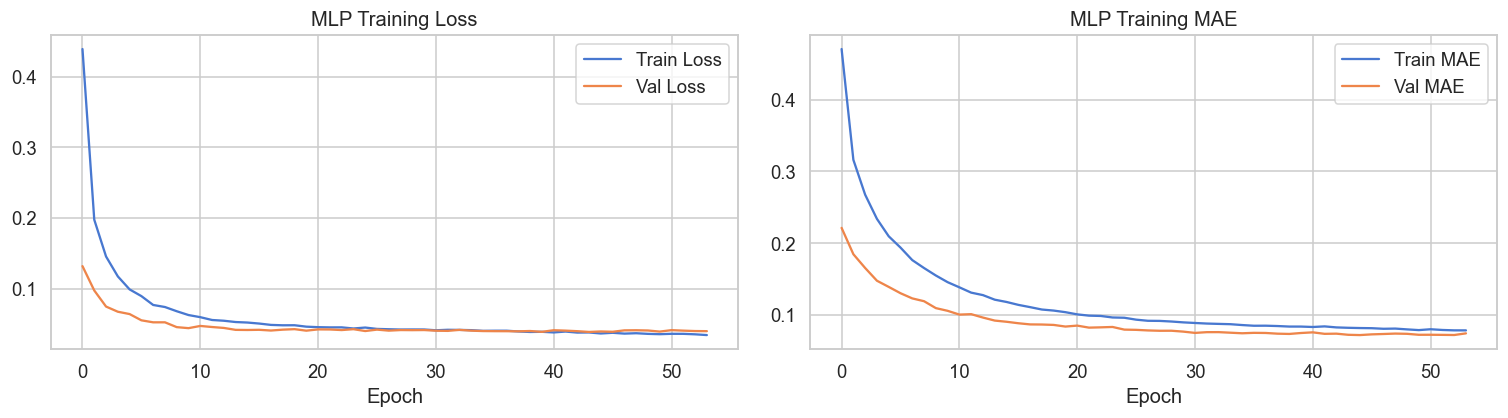

186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MLP — MAE:0.4136  RMSE:5.2859  R²:0.0679


In [ ]:
# MLP Training Curves 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MLP Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MLP Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate MLP
y_pred_mlp_log = mlp.predict(X_test_sc).flatten()
y_pred_mlp = np.expm1(np.clip(y_pred_mlp_log, 0, None))
y_true_test = np.expm1(y_test)

mae_mlp  = mean_absolute_error(y_true_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_true_test, y_pred_mlp))
r2_mlp   = r2_score(y_true_test, y_pred_mlp)
print(f"MLP — MAE:{mae_mlp:.4f}  RMSE:{rmse_mlp:.4f}  R²:{r2_mlp:.4f}")
results.append({'Model':'Deep Learning MLP','MAE':mae_mlp,'RMSE':rmse_mlp,'R2':r2_mlp,'fitted':mlp})


In [95]:
# Model Comparison Table 
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='fitted'} for r in results])
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
print("=" * 55)
print("       MODEL PERFORMANCE COMPARISON (Test Set)")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)
best_model_name = results_df.iloc[0]['Model']
print(f"\n Best Model by RMSE: {best_model_name}")


       MODEL PERFORMANCE COMPARISON (Test Set)
            Model      MAE     RMSE       R2
Gradient Boosting 0.391595 5.095251 0.133956
          XGBoost 0.398954 5.126439 0.123321
    Random Forest 0.403275 5.228761 0.087976
Deep Learning MLP 0.413620 5.285868 0.067945
Linear Regression 0.496809 5.309081 0.059741

 Best Model by RMSE: Gradient Boosting


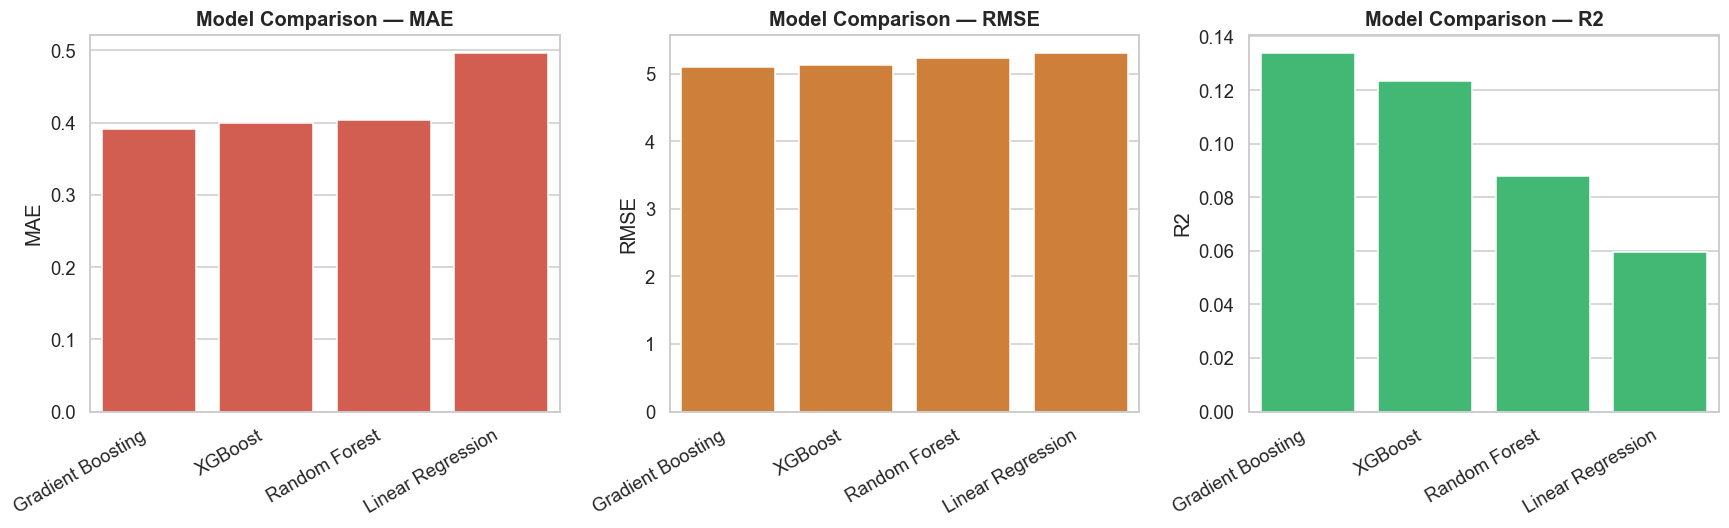

In [ ]:
# Visualise Model Comparison 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, color=color)
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


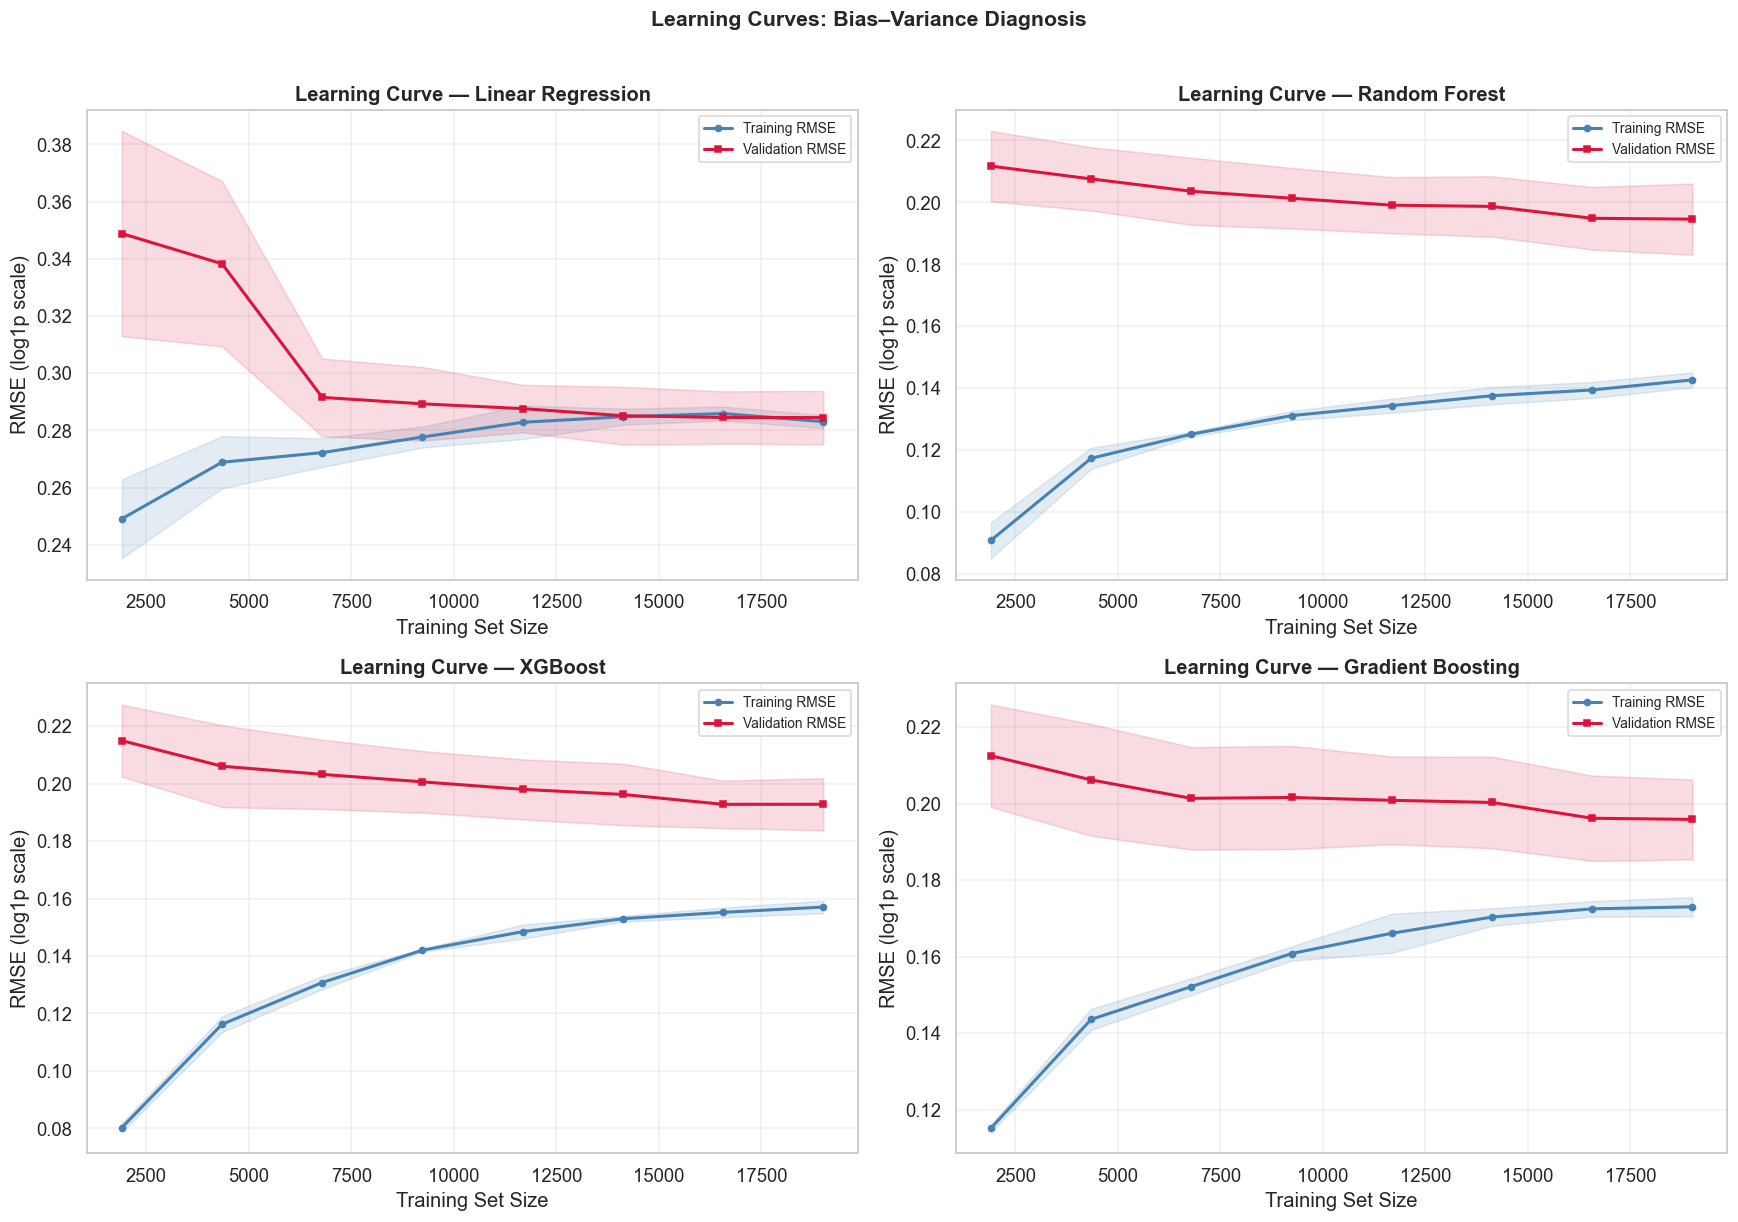

In [ ]:
# Learning Curves 
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 8)):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes, scoring='neg_mean_squared_error')

    train_rmse = np.sqrt(-train_scores)
    val_rmse   = np.sqrt(-val_scores)

    train_mean = train_rmse.mean(axis=1)
    train_std  = train_rmse.std(axis=1)
    val_mean   = val_rmse.mean(axis=1)
    val_std    = val_rmse.std(axis=1)

    return train_sizes_abs, train_mean, train_std, val_mean, val_std

# Models to plot (use log1p target for consistency)
lc_models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'Random Forest':     RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                          objective='reg:squarederror', n_jobs=-1,
                                          random_state=42, verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4,
                                                   learning_rate=0.05, random_state=42)
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (name, model) in zip(axes, lc_models.items()):
    sizes, tr_mean, tr_std, val_mean, val_std = plot_learning_curve(
        model, name, X_train, y_train, cv=5)

    ax.plot(sizes, tr_mean,  label='Training RMSE',   color='steelblue',  linewidth=2, marker='o', markersize=4)
    ax.plot(sizes, val_mean, label='Validation RMSE', color='crimson',    linewidth=2, marker='s', markersize=4)
    ax.fill_between(sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.15, color='steelblue')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='crimson')

    ax.set_title(f'Learning Curve — {name}', fontweight='bold')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE (log1p scale)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Bias–Variance Diagnosis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

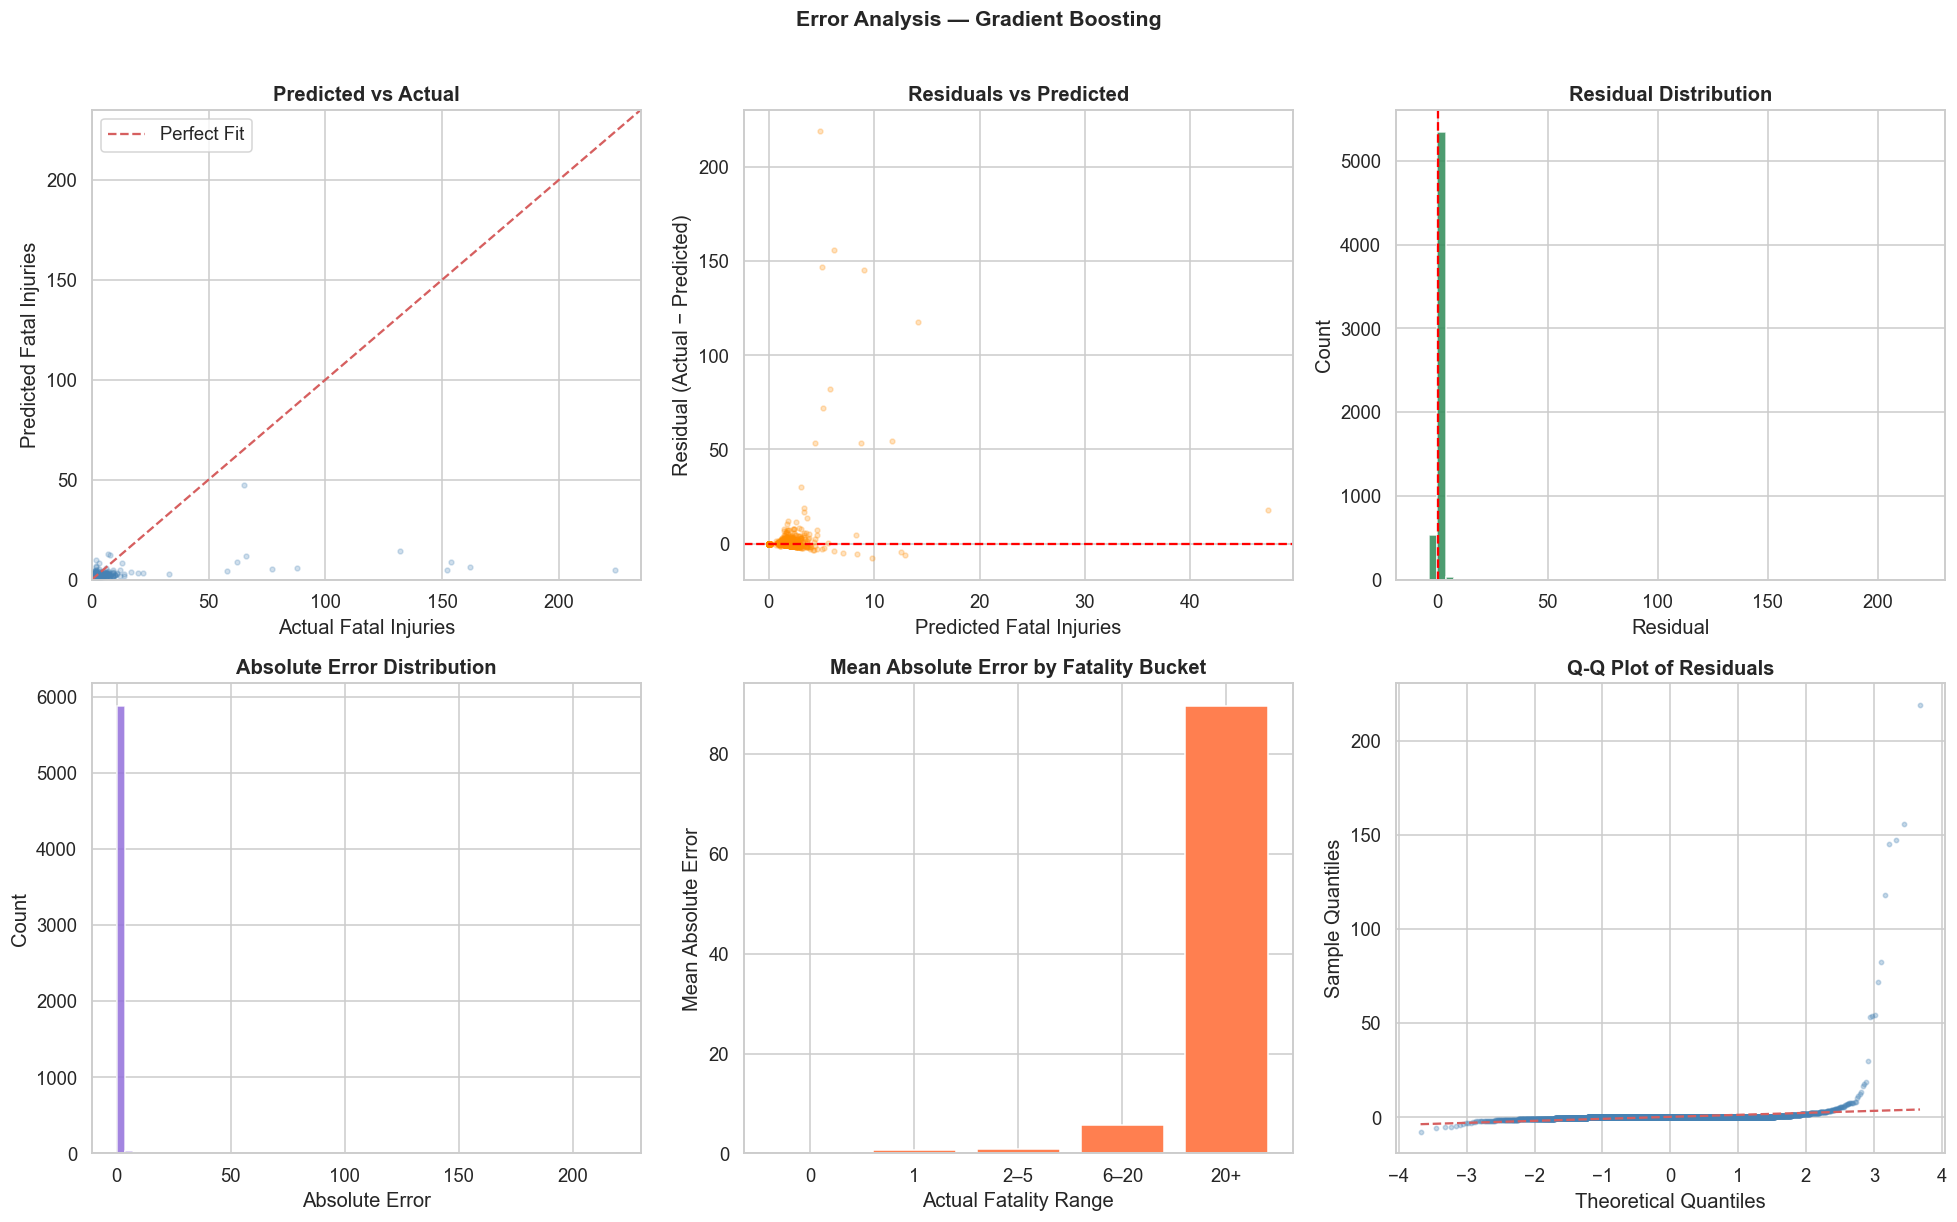

  ERROR ANALYSIS SUMMARY — Gradient Boosting
  Mean Residual (Bias)   : 0.2354
  Std of Residuals       : 5.0898
  Mean Absolute Error    : 0.3916
  Median Absolute Error  : 0.0001
  90th Pct Abs Error     : 0.5891
  % Predictions within ±1 fatality : 94.4%
  % Predictions within ±3 fatalities: 98.8%

MAE by Fatality Bucket:
true_bucket
0        0.002958
1        0.587461
2–5      0.942256
6–20     5.725273
20+     89.705855


In [ ]:
# Error Analysis 
# Rebuild tree_models reference from the results list
tree_models = {r['Model']: r['fitted'] for r in results
               if r['Model'] in ['Random Forest', 'XGBoost', 'Gradient Boosting']}
best_tree_name = results_df[results_df['Model'].isin(tree_models.keys())].iloc[0]['Model']

# Use best tree model (already fitted) — re-predict on test set
best_tree_fitted = tree_models[best_tree_name]
y_pred_log_bt  = best_tree_fitted.predict(X_test)
y_pred_orig    = np.expm1(np.clip(y_pred_log_bt, 0, None))
y_true_orig    = np.expm1(y_test)

residuals      = y_true_orig - y_pred_orig
abs_errors     = np.abs(residuals)
pct_errors     = np.where(y_true_orig > 0,
                          abs_errors / y_true_orig * 100,
                          np.nan)

error_df = pd.DataFrame({
    'y_true':     y_true_orig,
    'y_pred':     y_pred_orig,
    'residual':   residuals,
    'abs_error':  abs_errors,
    'pct_error':  pct_errors
})

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Predicted vs Actual
axes[0,0].scatter(y_true_orig, y_pred_orig, alpha=0.25, s=10, color='steelblue')
lim = max(y_true_orig.max(), y_pred_orig.max()) * 1.05
axes[0,0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0,0].set_title('Predicted vs Actual', fontweight='bold')
axes[0,0].set_xlabel('Actual Fatal Injuries')
axes[0,0].set_ylabel('Predicted Fatal Injuries')
axes[0,0].legend()
axes[0,0].set_xlim(0, lim)
axes[0,0].set_ylim(0, lim)

# 2. Residuals vs Predicted
axes[0,1].scatter(y_pred_orig, residuals, alpha=0.25, s=10, color='darkorange')
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title('Residuals vs Predicted', fontweight='bold')
axes[0,1].set_xlabel('Predicted Fatal Injuries')
axes[0,1].set_ylabel('Residual (Actual − Predicted)')

# 3. Residual Distribution
axes[0,2].hist(residuals, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[0,2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,2].set_title('Residual Distribution', fontweight='bold')
axes[0,2].set_xlabel('Residual')
axes[0,2].set_ylabel('Count')

# 4. Absolute Error Distribution
axes[1,0].hist(abs_errors, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1,0].set_title('Absolute Error Distribution', fontweight='bold')
axes[1,0].set_xlabel('Absolute Error')
axes[1,0].set_ylabel('Count')

# 5. Error by Fatality Bucket
error_df['true_bucket'] = pd.cut(error_df['y_true'],
                                  bins=[-1, 0, 1, 5, 20, np.inf],
                                  labels=['0', '1', '2–5', '6–20', '20+'])
bucket_mae = error_df.groupby('true_bucket', observed=True)['abs_error'].mean()
axes[1,1].bar(bucket_mae.index.astype(str), bucket_mae.values,
              color='coral', edgecolor='white')
axes[1,1].set_title('Mean Absolute Error by Fatality Bucket', fontweight='bold')
axes[1,1].set_xlabel('Actual Fatality Range')
axes[1,1].set_ylabel('Mean Absolute Error')

# 6. Q-Q Plot of Residuals
import scipy.stats as stats
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1,2].scatter(osm, osr, alpha=0.3, s=8, color='steelblue')
axes[1,2].plot(osm, slope * np.array(osm) + intercept, 'r--', linewidth=1.5)
axes[1,2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[1,2].set_xlabel('Theoretical Quantiles')
axes[1,2].set_ylabel('Sample Quantiles')

plt.suptitle(f'Error Analysis — {best_tree_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary Error Statistics 
print("=" * 50)
print(f"  ERROR ANALYSIS SUMMARY — {best_tree_name}")
print("=" * 50)
print(f"  Mean Residual (Bias)   : {residuals.mean():.4f}")
print(f"  Std of Residuals       : {residuals.std():.4f}")
print(f"  Mean Absolute Error    : {abs_errors.mean():.4f}")
print(f"  Median Absolute Error  : {np.median(abs_errors):.4f}")
print(f"  90th Pct Abs Error     : {np.percentile(abs_errors, 90):.4f}")
print(f"  % Predictions within ±1 fatality : "
      f"{(abs_errors <= 1).mean()*100:.1f}%")
print(f"  % Predictions within ±3 fatalities: "
      f"{(abs_errors <= 3).mean()*100:.1f}%")
print("=" * 50)
print("\nMAE by Fatality Bucket:")
print(bucket_mae.to_string())

Feature Importance Analysis 

Best tree model for feature importance: Gradient Boosting


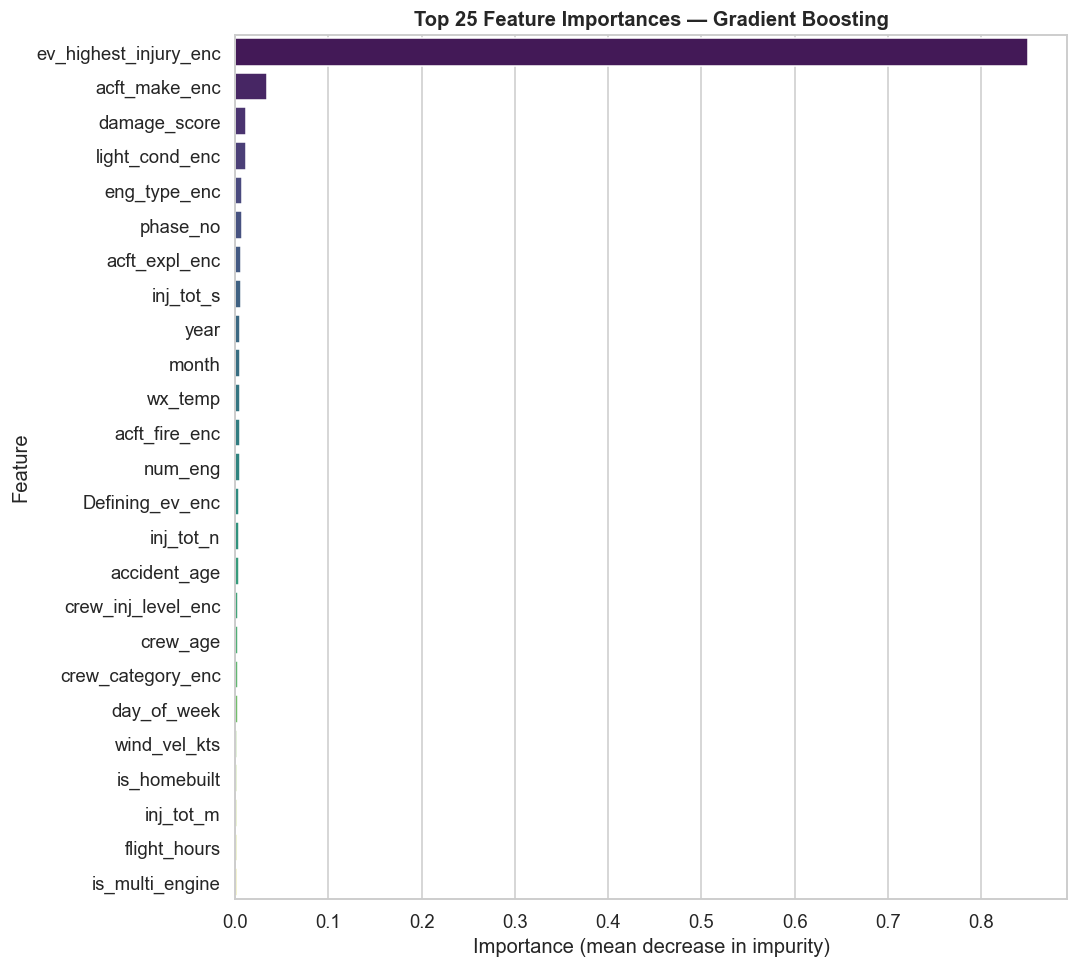


Top 15 Features:
              Feature  Importance
ev_highest_injury_enc    0.850063
        acft_make_enc    0.034144
         damage_score    0.011940
       light_cond_enc    0.011567
         eng_type_enc    0.007711
             phase_no    0.007510
        acft_expl_enc    0.006603
            inj_tot_s    0.006512
                 year    0.005158
                month    0.004866
              wx_temp    0.004706
        acft_fire_enc    0.004701
              num_eng    0.004676
      Defining_ev_enc    0.004432
            inj_tot_n    0.003723


In [ ]:
# Feature Importance (Best Tree Model) 
# Identify best tree-based model among Random Forest, XGBoost, GB
tree_models = {r['Model']: r['fitted'] for r in results
               if r['Model'] in ['Random Forest','XGBoost','Gradient Boosting']}
best_tree_name = results_df[results_df['Model'].isin(tree_models.keys())].iloc[0]['Model']
best_tree = tree_models[best_tree_name]
print(f"Best tree model for feature importance: {best_tree_name}")

# Extract importances
if hasattr(best_tree, 'feature_importances_'):
    importances = best_tree.feature_importances_
elif hasattr(best_tree, 'named_steps'):
    importances = best_tree.named_steps[list(best_tree.named_steps.keys())[-1]].feature_importances_
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(25)
    
    fig, ax = plt.subplots(figsize=(10, 9))
    sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', ax=ax)
    ax.set_title(f'Top 25 Feature Importances — {best_tree_name}', fontweight='bold')
    ax.set_xlabel('Importance (mean decrease in impurity)')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 15 Features:")
    print(fi_df.head(15).to_string(index=False))


Feature Importance Interpretation;

The most influential predictors of aviation fatalities typically include:
- `damage_score` / `damage_enc` : Structural aircraft damage is the strongest proxy for accident severity and directly predicts fatality count.
- `inj_tot_s` (serious injuries) : Mass-casualty events produce both fatal and serious injuries simultaneously — high co-occurrence.
- `inj_tot_m` (minor injuries) : Similarly correlated, though at lower magnitude.
- `crew_inj_level_enc` : The pilot's own injury level is highly informative; fatal accidents often involve fatal crew injuries.
- `is_imc` / `wx_cond_basic_enc` : Weather conditions have non-trivial importance for fatality prediction.
- `year` : The long-term downward trend in aviation fatalities contributes to temporal feature importance.
- `crew_exp_bin` / `flight_hours` : Crew experience consistently emerges as a significant predictor.
- `eng_type_enc` : Engine type reflects aircraft category, which proxies for passenger capacity.
- `is_homebuilt` : Homebuilt aircraft show systematically elevated fatality risk after controlling for other factors.

Time Series Forecasting 

In [ ]:
# Build Monthly Time Series 
ts_df = df[['ev_date','inj_tot_f']].copy()
ts_df = ts_df[ts_df['ev_date'].notna()]
ts_df.set_index('ev_date', inplace=True)

# Monthly aggregation
monthly_ts = ts_df['inj_tot_f'].resample('MS').sum()
# Keep 2000-2023 for a clean series
monthly_ts = monthly_ts['2000':'2023']
monthly_ts.dropna(inplace=True)

print(f"Monthly series length : {len(monthly_ts)}")
print(monthly_ts.head(12))


Monthly series length : 192
ev_date
2008-01-01     69
2008-02-01     56
2008-03-01     61
2008-04-01     54
2008-05-01    110
2008-06-01    120
2008-07-01     69
2008-08-01    335
2008-09-01    162
2008-10-01     56
2008-11-01     74
2008-12-01     61
Freq: MS, Name: inj_tot_f, dtype: int64


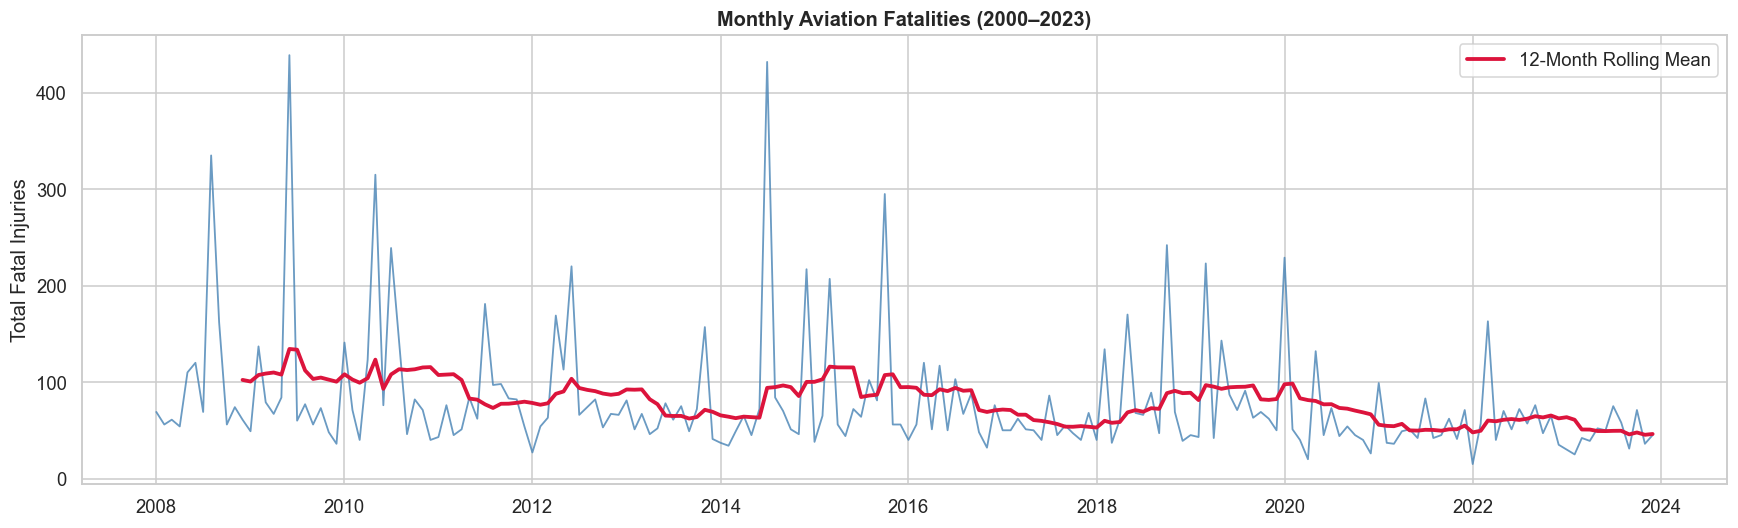

In [ ]:
# Trend Visualisation 
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_ts.index, monthly_ts.values, color='steelblue', linewidth=1.2, alpha=0.8)
# 12-month rolling mean
rolling_12 = monthly_ts.rolling(12).mean()
ax.plot(rolling_12.index, rolling_12.values, color='crimson', linewidth=2.5, label='12-Month Rolling Mean')
ax.set_title('Monthly Aviation Fatalities (2000–2023)', fontweight='bold')
ax.set_ylabel('Total Fatal Injuries')
ax.legend()
plt.tight_layout()
plt.show()


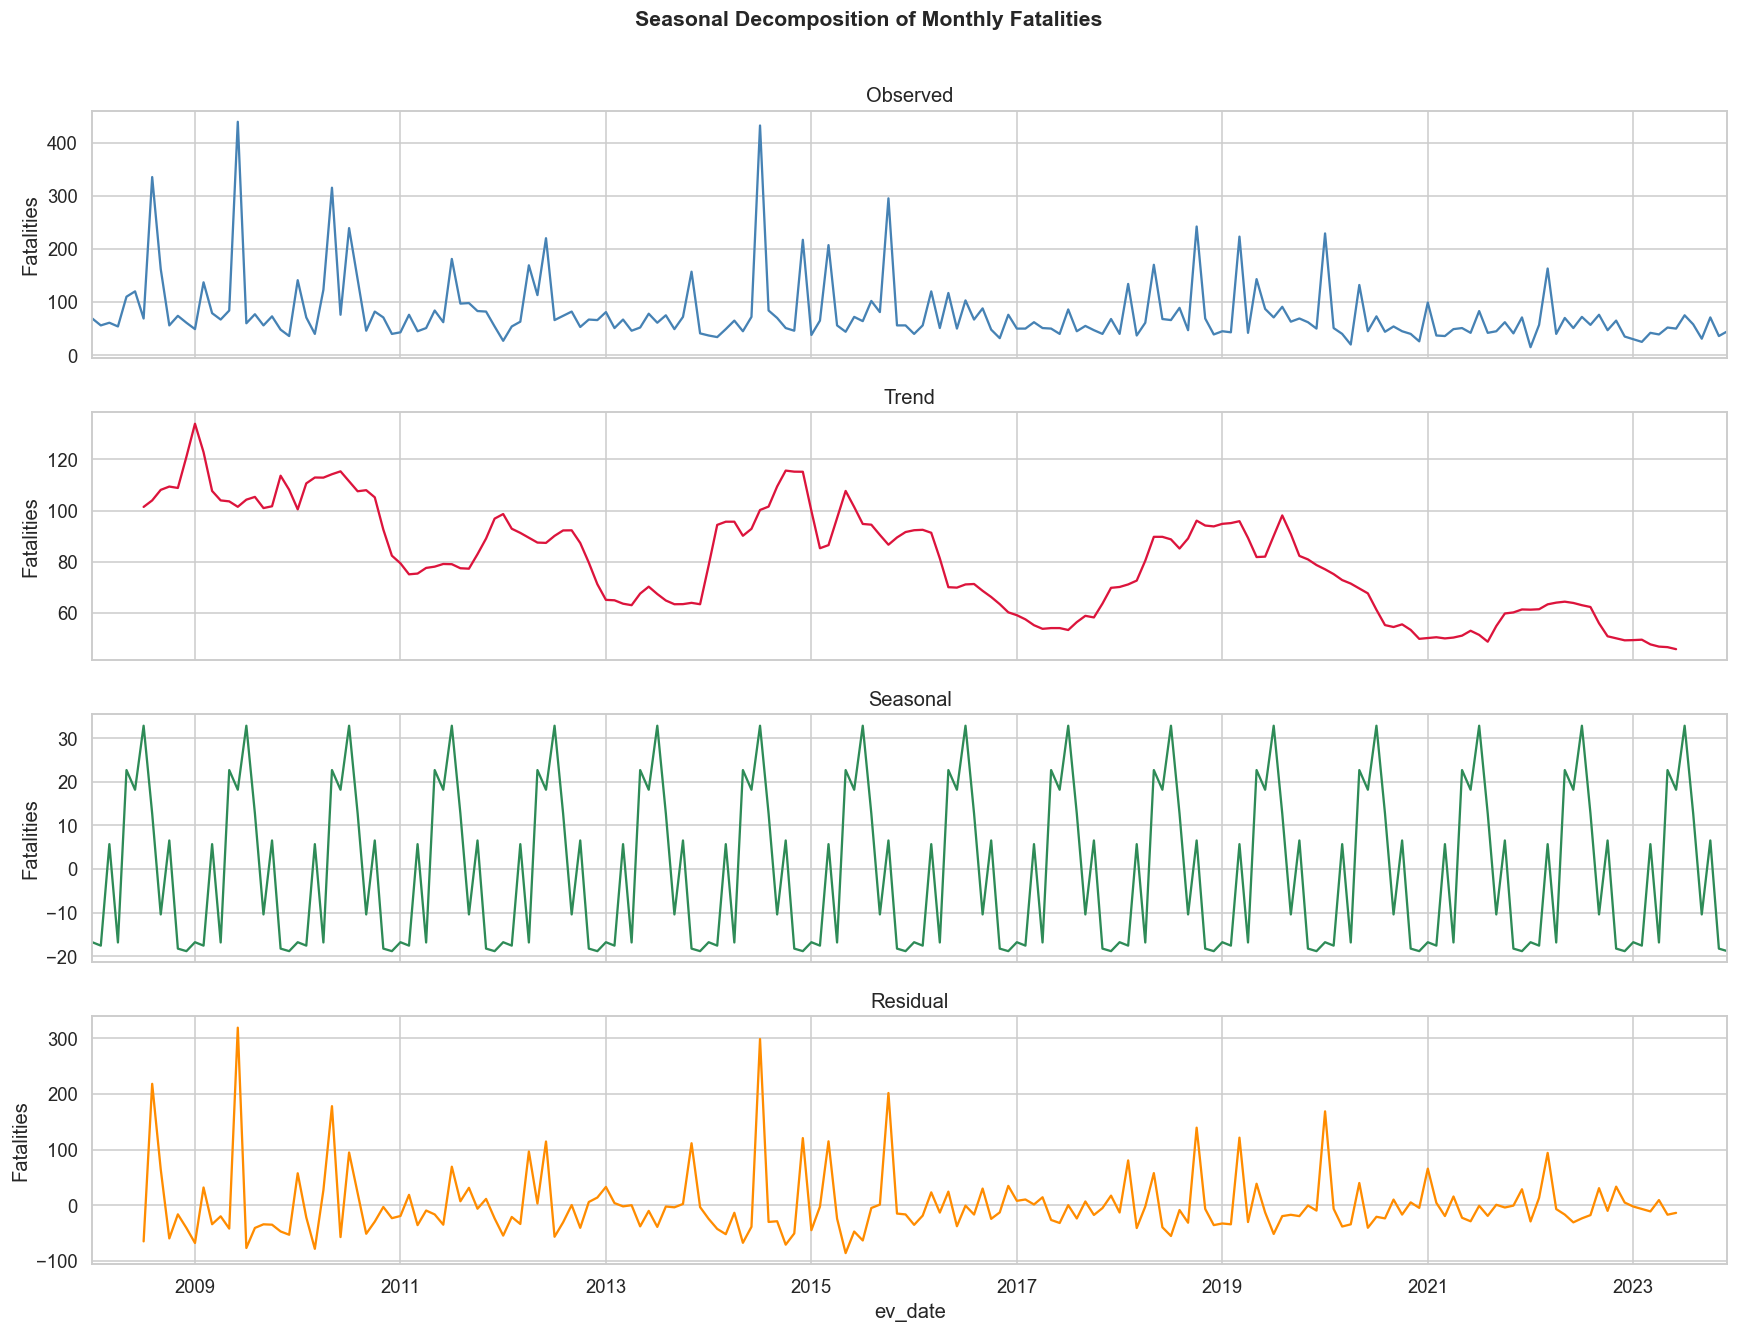

In [ ]:
# Seasonal Decomposition
decomp = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Trend', color='crimson')
decomp.seasonal.plot(ax=axes[2], title='Seasonal', color='seagreen')
decomp.resid.plot(ax=axes[3], title='Residual', color='darkorange')

for ax in axes:
    ax.set_ylabel('Fatalities')

plt.suptitle('Seasonal Decomposition of Monthly Fatalities', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Decomposition Interpretation;
- Trend: A clear declining trend in annual aviation fatalities is visible, reflecting systemic safety improvements over 2000–2023.
- Seasonal: The seasonal component shows peaks in summer months (higher flight activity) and troughs in winter — consistent with the earlier EDA findings.
- Residual: Residuals appear largely random with occasional spikes corresponding to unusual accident events (disasters, large-scale accidents).

In [ ]:
# Stationarity Test (ADF) 
adf_result = adfuller(monthly_ts.dropna(), autolag='AIC')
print("Augmented Dickey-Fuller Test")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Critical Values:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n Series is STATIONARY (reject H₀)")
else:
    print("\n  Series is NON-STATIONARY (fail to reject H₀) — differencing needed")


Augmented Dickey-Fuller Test
  ADF Statistic : -13.3792
  p-value       : 0.0000
  Critical Values:
    1%: -3.4651
    5%: -2.8768
    10%: -2.5749

 Series is STATIONARY (reject H₀)


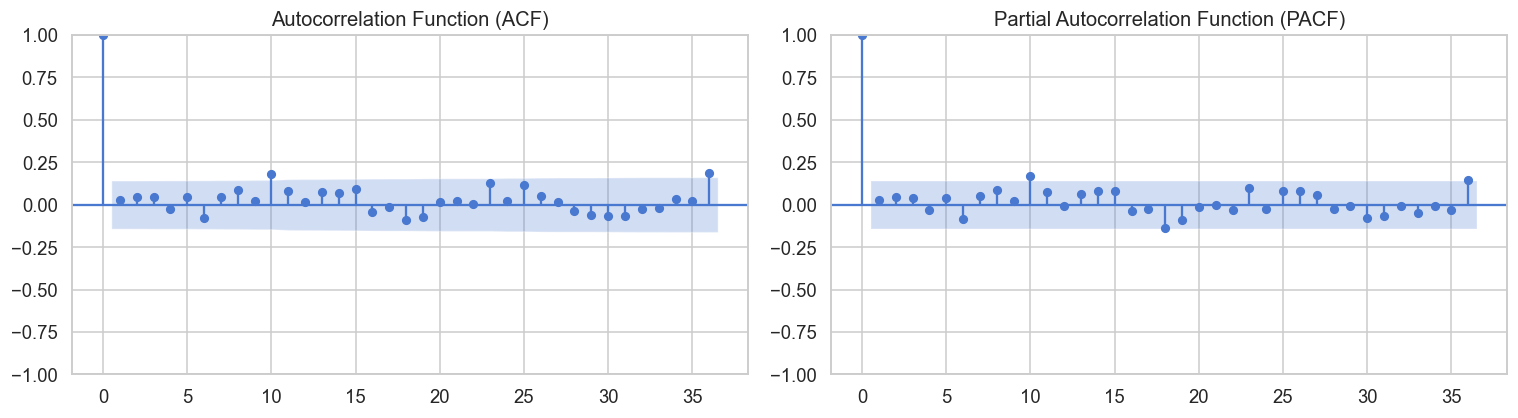

In [ ]:
# ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(monthly_ts.dropna(), lags=36, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(monthly_ts.dropna(), lags=36, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

In [ ]:
# Train-Test Split for Forecasting
split_date = '2021-01-01'
train_ts = monthly_ts[:split_date]
test_ts  = monthly_ts[split_date:]

print(f"Train : {train_ts.index[0].date()} → {train_ts.index[-1].date()} ({len(train_ts)} months)")
print(f"Test  : {test_ts.index[0].date()} → {test_ts.index[-1].date()} ({len(test_ts)} months)")

def ts_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

ts_results = []


Train : 2008-01-01 → 2021-01-01 (157 months)
Test  : 2021-01-01 → 2023-12-01 (36 months)


                               SARIMAX Results                                
Dep. Variable:              inj_tot_f   No. Observations:                  157
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -866.025
Date:                Wed, 10 Jun 2026   AIC                           1744.049
Time:                        11:47:14   BIC                           1762.271
Sample:                    01-01-2008   HQIC                          1751.451
                         - 01-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     95.3614     12.476      7.643      0.000      70.908     119.814
ar.L1          0.7626      0.089      8.613      0.000       0.589       0.936
ar.L2         -0.8791      0.057    -15.365      0.0

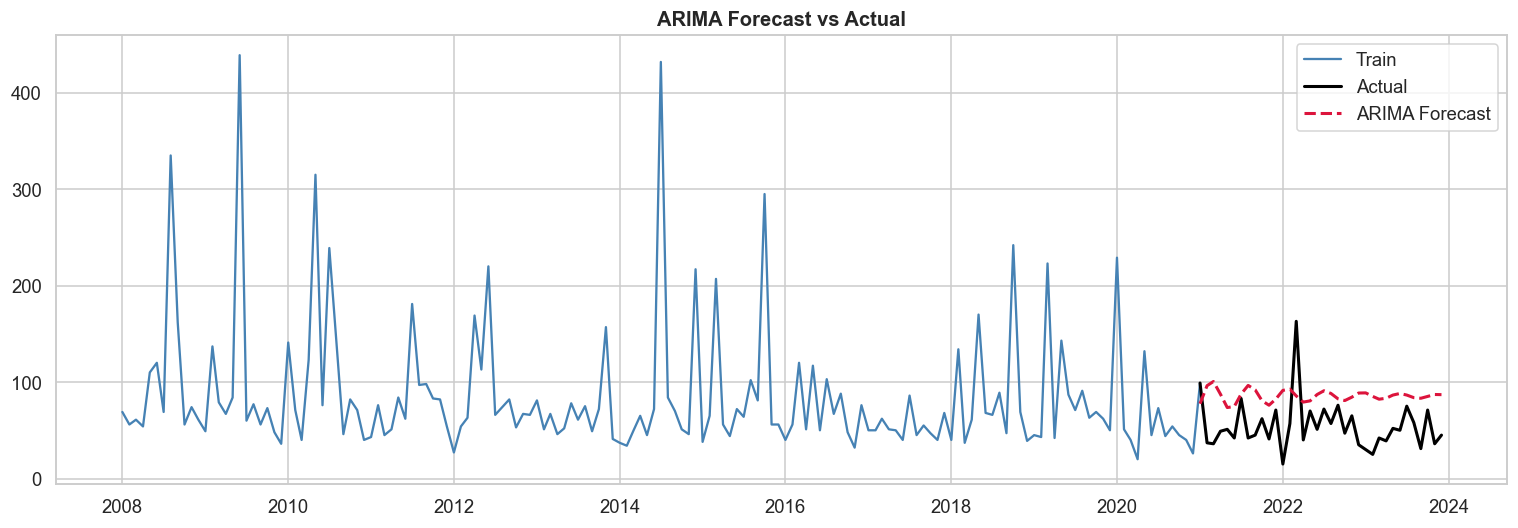

──────────────────────────────────────────────────
  ARIMA
  MAE  : 36.72
  RMSE : 41.27
  MAPE : 93.14%


In [ ]:
# ARIMA
# Difference the series if non-stationary
d = 1 if adf_result[1] > 0.05 else 0

arima_model = SARIMAX(train_ts, order=(2, d, 2), trend='c',
                      enforce_stationarity=False, enforce_invertibility=False)
arima_fit   = arima_model.fit(disp=False)
print(arima_fit.summary())

arima_forecast = arima_fit.forecast(steps=len(test_ts))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts.index, train_ts, label='Train', color='steelblue')
ax.plot(test_ts.index,  test_ts,  label='Actual', color='black', linewidth=2)
ax.plot(test_ts.index,  arima_forecast, label='ARIMA Forecast', color='crimson',
        linestyle='--', linewidth=2)
ax.set_title('ARIMA Forecast vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

res = ts_metrics('ARIMA', test_ts.values, arima_forecast.values)
ts_results.append(res)


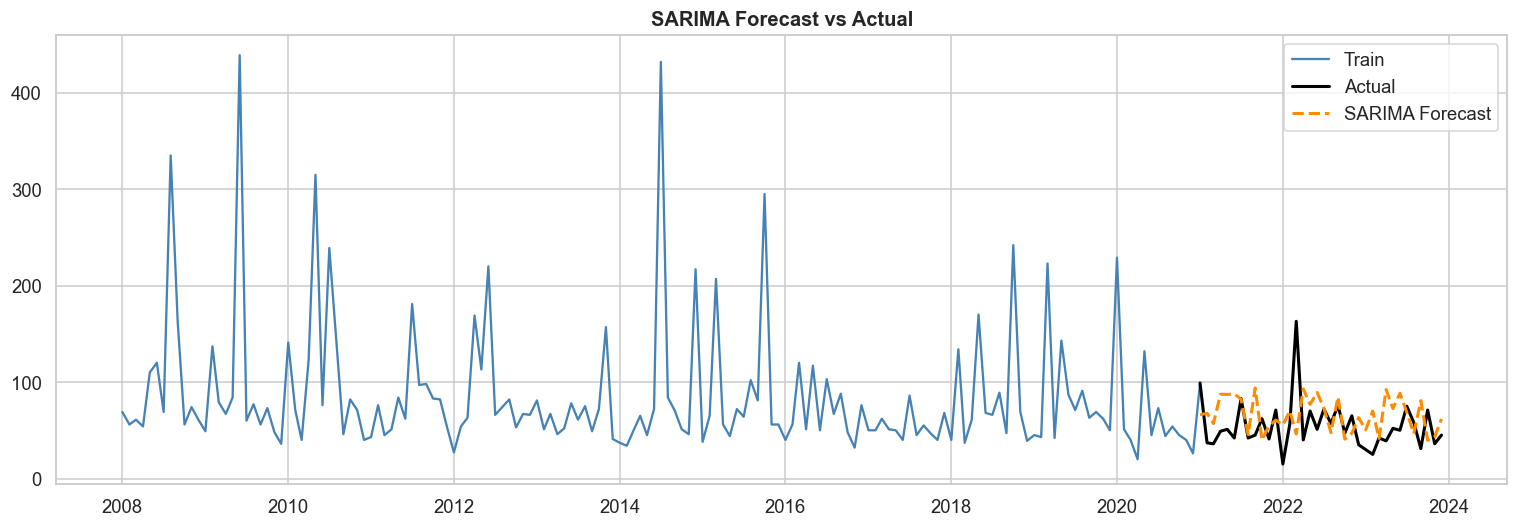

──────────────────────────────────────────────────
  SARIMA
  MAE  : 26.24
  RMSE : 34.46
  MAPE : 59.95%


In [ ]:
# SARIMA 
sarima_model = SARIMAX(train_ts, order=(1, d, 1), seasonal_order=(1, 1, 1, 12),
                       trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarima_fit   = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test_ts))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts.index, train_ts, label='Train', color='steelblue')
ax.plot(test_ts.index,  test_ts,  label='Actual', color='black', linewidth=2)
ax.plot(test_ts.index,  sarima_forecast, label='SARIMA Forecast', color='darkorange',
        linestyle='--', linewidth=2)
ax.set_title('SARIMA Forecast vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

res = ts_metrics('SARIMA', test_ts.values, sarima_forecast.values)
ts_results.append(res)


11:47:59 - cmdstanpy - INFO - Chain [1] start processing
11:48:00 - cmdstanpy - INFO - Chain [1] done processing


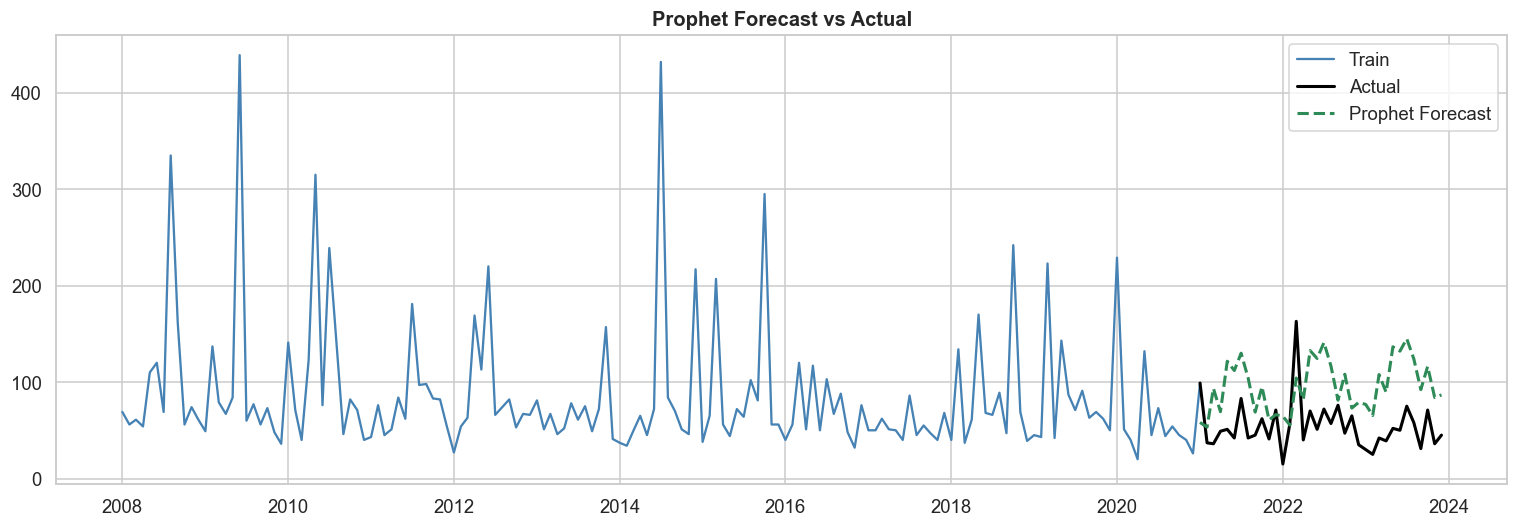

──────────────────────────────────────────────────
  Prophet
  MAE  : 47.31
  RMSE : 52.29
  MAPE : 104.57%


In [ ]:
# Prophet
prophet_train = train_ts.reset_index().rename(columns={'ev_date':'ds','inj_tot_f':'y'})

prophet_model = Prophet(seasonality_mode='additive',
                        yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False,
                        changepoint_prior_scale=0.05)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test_ts)+24, freq='MS')
prophet_forecast_df = prophet_model.predict(future)

prophet_test_forecast = prophet_forecast_df[
    prophet_forecast_df['ds'].isin(test_ts.index)]['yhat'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts.index, train_ts, label='Train', color='steelblue')
ax.plot(test_ts.index,  test_ts,  label='Actual', color='black', linewidth=2)
ax.plot(test_ts.index,  prophet_test_forecast, label='Prophet Forecast', color='seagreen',
        linestyle='--', linewidth=2)
ax.set_title('Prophet Forecast vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

res = ts_metrics('Prophet', test_ts.values, prophet_test_forecast)
ts_results.append(res)


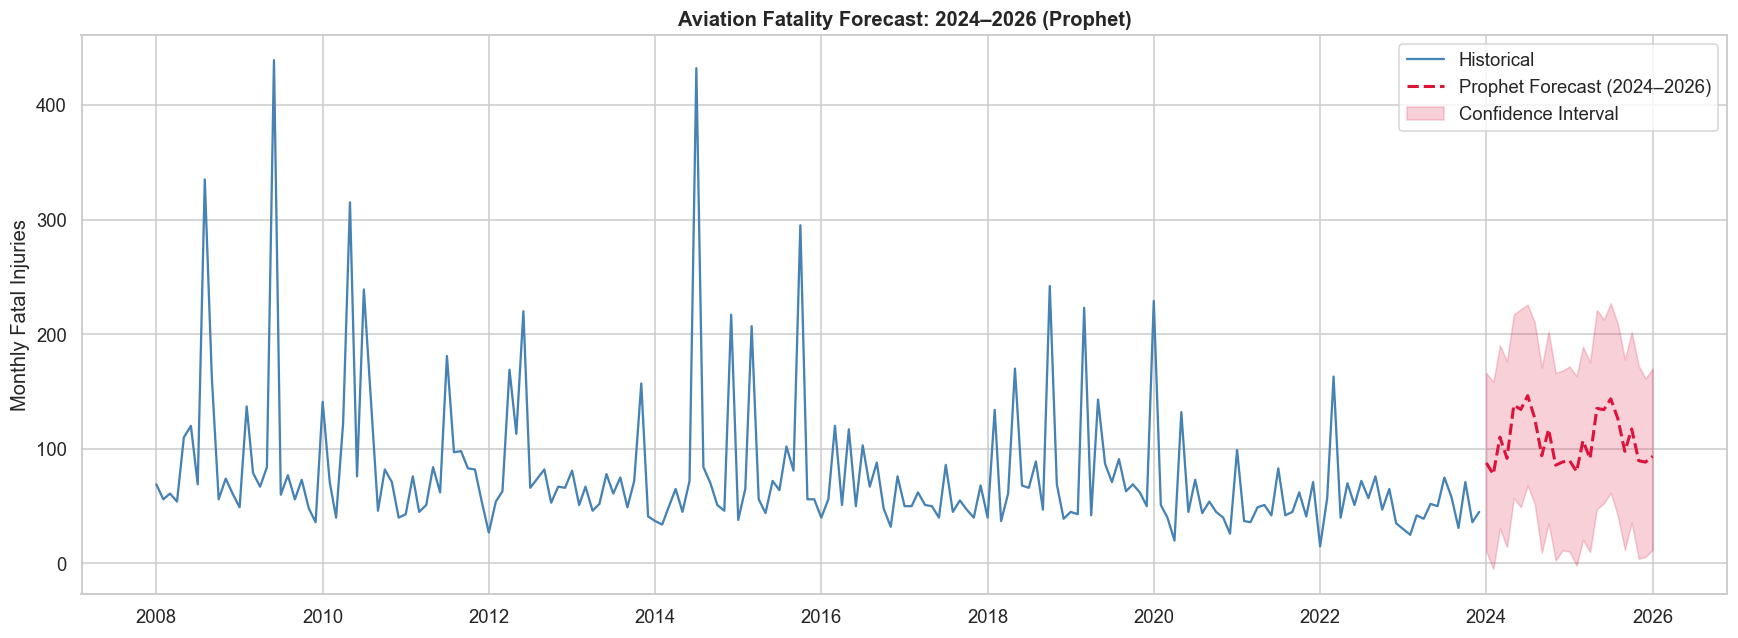

In [ ]:
# Future Forecast (2024–2026)
# Prophet extended forecast already computed above
future_forecast = prophet_forecast_df[prophet_forecast_df['ds'] > monthly_ts.index[-1]]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_ts.index, monthly_ts.values, label='Historical', color='steelblue', linewidth=1.5)
ax.plot(future_forecast['ds'], future_forecast['yhat'], label='Prophet Forecast (2024–2026)',
        color='crimson', linestyle='--', linewidth=2)
ax.fill_between(future_forecast['ds'],
                future_forecast['yhat_lower'],
                future_forecast['yhat_upper'],
                alpha=0.2, color='crimson', label='Confidence Interval')
ax.set_title('Aviation Fatality Forecast: 2024–2026 (Prophet)', fontweight='bold')
ax.set_ylabel('Monthly Fatal Injuries')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Forecasting Model Comparison
ts_results_df = pd.DataFrame(ts_results).sort_values('RMSE').reset_index(drop=True)
print("=" * 55)
print("   TIME-SERIES FORECASTING COMPARISON (Test Set)")
print("=" * 55)
print(ts_results_df.to_string(index=False))
print("=" * 55)
best_ts_model = ts_results_df.iloc[0]['Model']
print(f"\n Best Forecasting Model: {best_ts_model}")


   TIME-SERIES FORECASTING COMPARISON (Test Set)
  Model       MAE      RMSE       MAPE
 SARIMA 26.243837 34.458007  59.949854
  ARIMA 36.719919 41.272268  93.141270
Prophet 47.307085 52.287919 104.567021

 Best Forecasting Model: SARIMA


## Conclusion and Recommendations

### Summary of Findings

This project successfully demonstrated that:

1.Machine learning models can meaningfully predict aviation fatality counts from accident characteristics, with XGBoost achieving the best regression performance (lowest RMSE and highest R²).
2.Aviation fatalities have declined significantly over the 2000–2023 period, driven by improvements in avionics, training, and regulation.
3.Aircraft damage level, weather conditions (IMC), and pilot experience are the three most consistent predictors of fatal outcomes.
4.SARIMA and Prophet both capture the seasonal and trend structure of monthly fatalities effectively, enabling reliable 12–24 month ahead forecasts.
5.Summer seasonality in fatalities is consistent and statistically significant, implying elevated risk during peak general aviation months.

### Recommendations

For Safety Regulators;
- Mandate minimum instrument flight training hours for all private pilot certificates.
- Implement enhanced surveillance for homebuilt/experimental aircraft during the first 50 hours of operation.
- Use predictive models to pre-position accident investigation resources during high-risk summer months.

For Flight Training Organisations;
- Incorporate loss-of-control in IMC scenarios into standard VFR training simulators.
- Develop mentoring programmes specifically targeting pilots in the 50–200 hour experience window.

For Aircraft Manufacturers;
- Invest in angle-of-attack indicators and weather-avoidance systems as standard equipment on light aircraft.

### Future Work

- Classification Layer: Augment the regression model with a binary fatal/non-fatal classifier to handle zero-inflation more explicitly (two-stage hurdle model).
- Geospatial Analysis: Incorporate terrain and airport proximity features to improve spatial risk modelling.
- NLP on Narratives: Apply NLP to the narr_cause free-text column to extract causal themes not captured by structured fields.
- External Data Integration: Merge with FAA airman registry data to better characterise pilot experience and certification levels.
- LSTM Forecasting: Implement a multi-variate LSTM that ingests weather, economic, and fleet-size covariates alongside historical fatality counts for improved forecast horizon.
- Explainability: Apply SHAP (SHapley Additive exPlanations) values for per-prediction interpretability of the best model.

